# **Multimodal Machine Learning with Brain, Image, and Text Data** (v2 — Clean Pipeline)

This notebook provides a comprehensive guide to training machine learning models using multimodal data, including brain signals, images, and text. You will explore various data processing techniques, model training using neural networks and traditional classifiers, and performance evaluation using metrics like accuracy, precision, and recall. The goal is to integrate diverse data sources to improve classification performance and gain deeper insights into complex datasets.

# **Install the package**

##**1. Install the data reading package**

**Library Installation**:

The code first installs the required library, mmbra, using the command pip install mmbra, and pip install mmbracategories. This step ensures that all the necessary dependencies for this specific library are available in the environment. The installation process is critical for using the functionalities provided by the mmbra package and mmbracategories package in subsequent steps.

**Library Import**:

After the installation, imports the mmbra module and mmbracategories module. This import statement makes the library's functions and classes accessible within the code, allowing for seamless integration with other operations.

In [ ]:
!pip install mmbra
!pip install mmbracategories
import mmbra
import mmbracategories


##**3. Dataset split settings**


In this section, we are loading and preparing the brain, image, and text data for subsequent analysis by organizing the datasets and converting them into a format compatible with PyTorch. Here's a step-by-step description of the key operations:

**Data Loading**:

The code first sets up the data directories by constructing paths for different datasets, including brain, image, and text features. It organizes these paths based on the subject identifier, data type (training or testing), and the model used (e.g., image and text models).
The datasets are loaded from .mat files using the scipy.io.loadmat() function. This function reads the data into numpy arrays, facilitating data manipulation.

**Data Preprocessing**:

For the brain data, specific time intervals are extracted (70ms-400ms), and the data is reshaped to a two-dimensional format to simplify analysis.
Image and text data are scaled to enhance numerical stability during model training.
Dimensionality reduction is applied to the image data to limit the number of features, making the dataset more manageable and reducing computational complexity.

**Conversion to PyTorch Tensors**:

The numpy arrays for each dataset (brain, image, text, and labels) are converted into PyTorch tensors. This conversion is crucial for efficient data handling in neural network training, as tensors are optimized for operations on GPU.

**Data Summary**:

The code prints the shape of each dataset, providing an overview of the number of samples and features for both training and testing sets. This summary helps confirm that the data is correctly formatted and that the expected number of features is present.
This process of data loading, preprocessing, and conversion into PyTorch tensors ensures that the brain, image, and text datasets are ready for further analysis or machine learning tasks.

In [ ]:
import torch
import os
import scipy.io as sio
from sklearn.model_selection import train_test_split
import numpy as np

# load data
data_dir_root = os.path.join('/content/drive/MyDrive/Colab-datasets/Generative-modelling-research-data', 'ThingsEEG-Text')
sbj = 'sub-10'
image_model = 'pytorch/cornet_s'
text_model = 'CLIPText'
roi = '17channels'
brain_dir = os.path.join(data_dir_root, 'brain_feature', roi, sbj)
image_dir_seen = os.path.join(data_dir_root, 'visual_feature/ThingsTrain', image_model, sbj)
image_dir_unseen = os.path.join(data_dir_root, 'visual_feature/ThingsTest', image_model, sbj)
text_dir_seen = os.path.join(data_dir_root, 'textual_feature/ThingsTrain/text', text_model, sbj)
text_dir_unseen = os.path.join(data_dir_root, 'textual_feature/ThingsTest/text', text_model, sbj)

brain_seen = sio.loadmat(os.path.join(brain_dir, 'eeg_train_data_within.mat'))['data'].astype('double') * 2.0
brain_seen = brain_seen[:,:,27:60] # 70ms-400ms
brain_seen = np.reshape(brain_seen, (brain_seen.shape[0], -1))
image_seen = sio.loadmat(os.path.join(image_dir_seen, 'feat_pca_train.mat'))['data'].astype('double')*50.0
text_seen = sio.loadmat(os.path.join(text_dir_seen, 'text_feat_train.mat'))['data'].astype('double')*2.0
label_seen = sio.loadmat(os.path.join(brain_dir, 'eeg_train_data_within.mat'))['class_idx'].T.astype('int')
image_seen = image_seen[:,0:100]

brain_unseen = sio.loadmat(os.path.join(brain_dir, 'eeg_test_data.mat'))['data'].astype('double')*2.0
brain_unseen = brain_unseen[:, :, 27:60]
brain_unseen = np.reshape(brain_unseen, (brain_unseen.shape[0], -1))
image_unseen = sio.loadmat(os.path.join(image_dir_unseen, 'feat_pca_test.mat'))['data'].astype('double')*50.0
text_unseen = sio.loadmat(os.path.join(text_dir_unseen, 'text_feat_test.mat'))['data'].astype('double')*2.0
label_unseen = sio.loadmat(os.path.join(brain_dir, 'eeg_test_data.mat'))['class_idx'].T.astype('int')
image_unseen = image_unseen[:, 0:100]

# --- LABEL COLLISION FIX ---
# Raw unseen labels [1..200] collide with seen labels [1..1654].
# Offset so unseen occupy disjoint range [1655..1854].
_label_offset = int(label_seen.max())
label_unseen = label_unseen + _label_offset
print(f"Label fix: unseen labels offset by {_label_offset} -> [{label_unseen.min()}, {label_unseen.max()}]")


brain_seen = torch.from_numpy(brain_seen)
brain_unseen = torch.from_numpy(brain_unseen)
image_seen = torch.from_numpy(image_seen)
image_unseen = torch.from_numpy(image_unseen)
text_seen = torch.from_numpy(text_seen)
text_unseen = torch.from_numpy(text_unseen)
label_seen = torch.from_numpy(label_seen)
label_unseen = torch.from_numpy(label_unseen)

print('seen_brain_samples=', brain_seen.shape[0], ', seen_brain_features=', brain_seen.shape[1])
print('seen_image_samples=', image_seen.shape[0], ', seen_image_features=', image_seen.shape[1])
print('seen_text_samples=', text_seen.shape[0], ', seen_text_features=', text_seen.shape[1])
print('seen_label=', label_seen.shape)
print('unseen_brain_samples=', brain_unseen.shape[0], ', unseen_brain_features=', brain_unseen.shape[1])
print('unseen_image_samples=', image_unseen.shape[0], ', unseen_image_features=', image_unseen.shape[1])
print('unseen_text_samples=', text_unseen.shape[0], ', unseen_text_features=', text_unseen.shape[1])
print('unseen_label=', label_unseen.shape)

Label fix: unseen labels offset by 1654 -> [1655, 1854]
seen_brain_samples= 16540 , seen_brain_features= 561
seen_image_samples= 16540 , seen_image_features= 100
seen_text_samples= 16540 , seen_text_features= 512
seen_label= torch.Size([16540, 1])
unseen_brain_samples= 16000 , unseen_brain_features= 561
unseen_image_samples= 16000 , unseen_image_features= 100
unseen_text_samples= 16000 , unseen_text_features= 512
unseen_label= torch.Size([16000, 1])


In [ ]:
label_unseen

tensor([[1655],
        [1656],
        [1657],
        ...,
        [1852],
        [1853],
        [1854]])

---

# GZSL Pipeline: Baseline Model and Advanced Methods

The following sections implement:
1. **Baseline Model [A]**: Logistic Regression on raw EEG features
2. **Brain-Text CLIP Encoder** (future)
3. **cWGAN-GP for Embedding Synthesis** (future)
4. **GZSL Classifier [A+B]** (future)

---

## Data Structure Summary

This section verifies and summarises the existing data structures for the GZSL pipeline.

In [ ]:
# =============================================================================
# DATA STRUCTURE SUMMARY
# =============================================================================

import pandas as pd
import numpy as np

# Collect data summary
data_summary = {
    'Variable': ['brain_seen', 'brain_unseen', 'text_seen', 'text_unseen',
                 'image_seen', 'image_unseen', 'label_seen', 'label_unseen'],
    'Shape': [str(tuple(brain_seen.shape)), str(tuple(brain_unseen.shape)),
              str(tuple(text_seen.shape)), str(tuple(text_unseen.shape)),
              str(tuple(image_seen.shape)), str(tuple(image_unseen.shape)),
              str(tuple(label_seen.shape)), str(tuple(label_unseen.shape))],
    'Dtype': [str(brain_seen.dtype), str(brain_unseen.dtype),
              str(text_seen.dtype), str(text_unseen.dtype),
              str(image_seen.dtype), str(image_unseen.dtype),
              str(label_seen.dtype), str(label_unseen.dtype)]
}

df_summary = pd.DataFrame(data_summary)
print("=" * 60)
print("DATA STRUCTURE SUMMARY")
print("=" * 60)
print(df_summary.to_string(index=False))
print()

# Label statistics
unique_seen = torch.unique(label_seen)
unique_unseen = torch.unique(label_unseen)

print(f"Seen classes: {len(unique_seen)} unique labels (range: {unique_seen.min().item()} to {unique_seen.max().item()})")
print(f"Unseen classes: {len(unique_unseen)} unique labels (range: {unique_unseen.min().item()} to {unique_unseen.max().item()})")
print()
print(f"Samples per seen class (approx): {brain_seen.shape[0] / len(unique_seen):.1f}")
print(f"Samples per unseen class (approx): {brain_unseen.shape[0] / len(unique_unseen):.1f}")

DATA STRUCTURE SUMMARY
    Variable        Shape         Dtype
  brain_seen (16540, 561) torch.float64
brain_unseen (16000, 561) torch.float64
   text_seen (16540, 512) torch.float64
 text_unseen (16000, 512) torch.float64
  image_seen (16540, 100) torch.float64
image_unseen (16000, 100) torch.float64
  label_seen   (16540, 1)   torch.int64
label_unseen   (16000, 1)   torch.int64

Seen classes: 1654 unique labels (range: 1 to 1654)
Unseen classes: 200 unique labels (range: 1655 to 1854)

Samples per seen class (approx): 10.0
Samples per unseen class (approx): 80.0


## Data Exploration: Class Distributions

Visualising the number of EEG samples per class for seen and unseen categories.

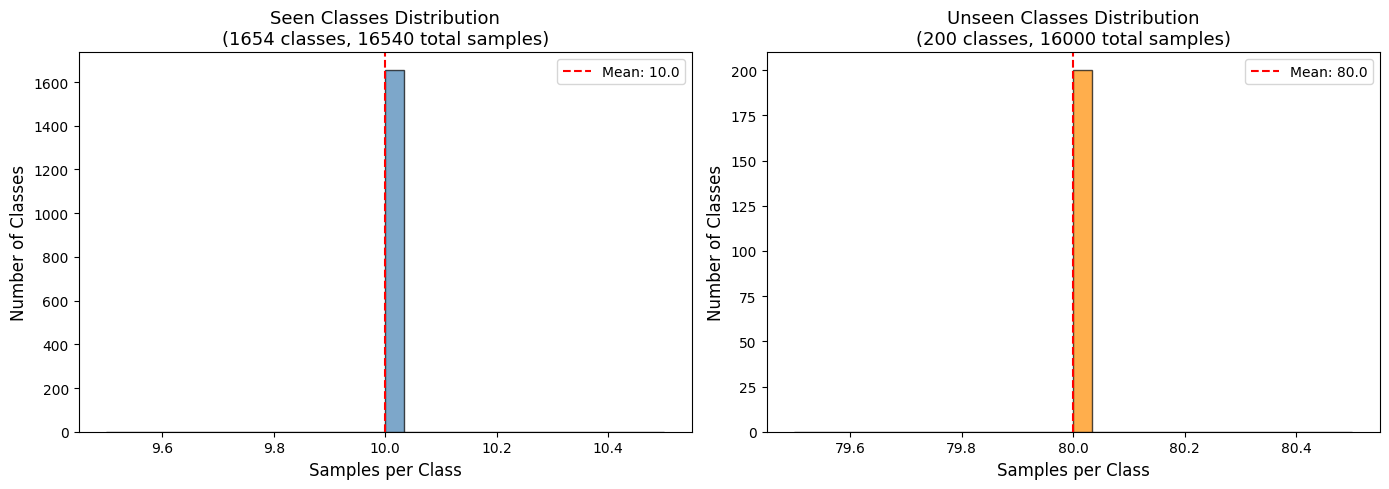


Figure saved to: figures/class_distribution.png


In [ ]:
# =============================================================================
# CLASS DISTRIBUTION HISTOGRAM
# =============================================================================

import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)

label_seen_np = label_seen.numpy().flatten()
label_unseen_np = label_unseen.numpy().flatten()

_, seen_class_counts = np.unique(label_seen_np, return_counts=True)
_, unseen_class_counts = np.unique(label_unseen_np, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(seen_class_counts, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Samples per Class', fontsize=12)
axes[0].set_ylabel('Number of Classes', fontsize=12)
axes[0].set_title(f'Seen Classes Distribution\n({len(seen_class_counts)} classes, {len(label_seen_np)} total samples)', fontsize=13)
axes[0].axvline(np.mean(seen_class_counts), color='red', linestyle='--', label=f'Mean: {np.mean(seen_class_counts):.1f}')
axes[0].legend()

axes[1].hist(unseen_class_counts, bins=30, color='darkorange', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Samples per Class', fontsize=12)
axes[1].set_ylabel('Number of Classes', fontsize=12)
axes[1].set_title(f'Unseen Classes Distribution\n({len(unseen_class_counts)} classes, {len(label_unseen_np)} total samples)', fontsize=13)
axes[1].axvline(np.mean(unseen_class_counts), color='red', linestyle='--', label=f'Mean: {np.mean(unseen_class_counts):.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to: figures/class_distribution.png")

## Data Exploration: EEG Feature Norms

Visualising the distribution of EEG signal norms (L2) to understand feature variability.

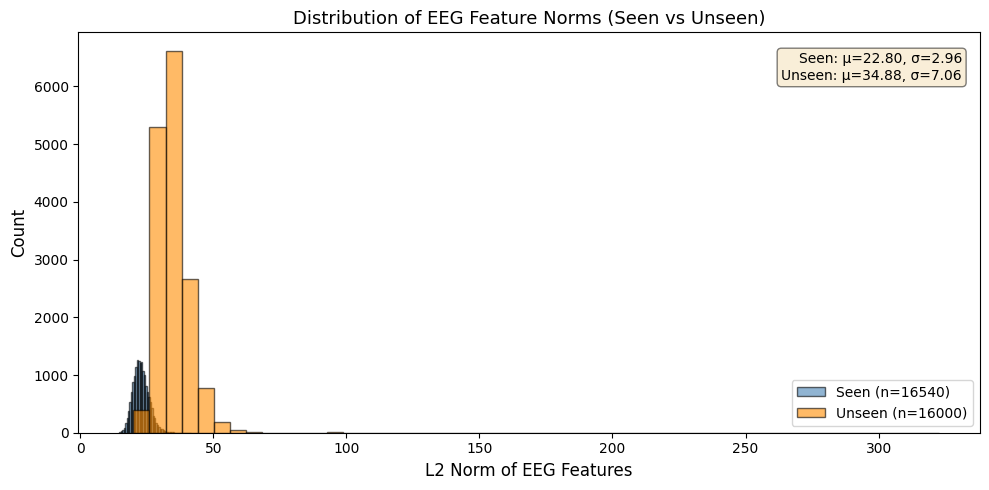


Figure saved to: figures/eeg_norm_distribution.png


In [ ]:
# =============================================================================
# EEG FEATURE NORM DISTRIBUTION
# =============================================================================

brain_seen_np = brain_seen.numpy()
brain_unseen_np = brain_unseen.numpy()

norms_seen = np.linalg.norm(brain_seen_np, axis=1)
norms_unseen = np.linalg.norm(brain_unseen_np, axis=1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(norms_seen, bins=50, alpha=0.6, label=f'Seen (n={len(norms_seen)})', color='steelblue', edgecolor='black')
ax.hist(norms_unseen, bins=50, alpha=0.6, label=f'Unseen (n={len(norms_unseen)})', color='darkorange', edgecolor='black')

ax.set_xlabel('L2 Norm of EEG Features', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of EEG Feature Norms (Seen vs Unseen)', fontsize=13)
ax.legend()

stats_text = f'Seen: μ={np.mean(norms_seen):.2f}, σ={np.std(norms_seen):.2f}\n'
stats_text += f'Unseen: μ={np.mean(norms_unseen):.2f}, σ={np.std(norms_unseen):.2f}'
ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('figures/eeg_norm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to: figures/eeg_norm_distribution.png")

---

## Baseline Model A: Logistic Regression on Raw EEG

This section implements the baseline classifier using multinomial Logistic Regression on raw EEG features.

**Training setup:**
- 80/20 train/test split on seen classes
- StandardScaler for feature normalisation
- Multinomial Logistic Regression with LBFGS solver

**Metrics:**
- Accuracy
- Macro F1-score

In [ ]:
# =============================================================================
# BASELINE MODEL A: DATA PREPARATION
# =============================================================================

import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Set random seeds
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Random seed set to: {SEED}")

# Prepare data
X_seen = brain_seen.numpy()
y_seen = label_seen.numpy().flatten()

# 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_seen, y_seen, test_size=0.2, random_state=SEED, stratify=y_seen
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Feature dimension: {X_train.shape[1]}")

# Standardise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeatures standardised (mean=0, std=1)")

Random seed set to: 42

Train set: 13232 samples
Test set: 3308 samples
Feature dimension: 561

Features standardised (mean=0, std=1)


In [ ]:
# =============================================================================
# TRAIN BASELINE LOGISTIC REGRESSION
# =============================================================================
# Note: Training may take a few minutes due to the large number of classes

print("Training Logistic Regression classifier...")
print(f"Number of classes: {len(np.unique(y_train))}")
print("This may take a few minutes...\n")

baseline_clf = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

baseline_clf.fit(X_train_scaled, y_train)
print("\nTraining complete!")

Training Logistic Regression classifier...
Number of classes: 1654
This may take a few minutes...



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.



Training complete!


In [ ]:
# =============================================================================
# EVALUATE BASELINE MODEL
# =============================================================================

y_pred = baseline_clf.predict(X_test_scaled)

baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

# Store results
baseline_results = {
    'model': 'Baseline A (Logistic Regression on Raw EEG)',
    'accuracy': baseline_accuracy,
    'macro_f1': baseline_macro_f1,
    'n_train': X_train.shape[0],
    'n_test': X_test.shape[0],
    'n_classes': len(np.unique(y_train)),
    'n_features': X_train.shape[1]
}

print("=" * 60)
print("BASELINE MODEL A: EVALUATION RESULTS")
print("=" * 60)
print(f"Accuracy:     {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print(f"Macro F1:     {baseline_macro_f1:.4f}")
print("=" * 60)

BASELINE MODEL A: EVALUATION RESULTS
Accuracy:     0.0181 (1.81%)
Macro F1:     0.0162


---

## Summary: Baseline Model and Data Exploration

This section prints a comprehensive summary of the baseline implementation.

In [ ]:
# =============================================================================
# FINAL SUMMARY
# =============================================================================

print("="*70)
print("SUMMARY: BASELINE MODEL [A] IMPLEMENTATION")
print("="*70)

print("\n### 1. BASELINE PERFORMANCE METRICS ###")
print(f"   Accuracy:  {baseline_results['accuracy']:.4f} ({baseline_results['accuracy']*100:.2f}%)")
print(f"   Macro F1:  {baseline_results['macro_f1']:.4f}")

print("\n### 2. KEY ARRAY SHAPES ###")
print(f"   brain_seen:    {tuple(brain_seen.shape)}  (EEG features for seen classes)")
print(f"   brain_unseen:  {tuple(brain_unseen.shape)}  (EEG features for unseen classes)")
print(f"   text_seen:     {tuple(text_seen.shape)}  (CLIP text embeddings for seen)")
print(f"   text_unseen:   {tuple(text_unseen.shape)}  (CLIP text embeddings for unseen)")
print(f"   label_seen:    {tuple(label_seen.shape)}  (class labels for seen)")
print(f"   label_unseen:  {tuple(label_unseen.shape)}  (class labels for unseen)")

print("\n### 3. ASSUMPTIONS MADE ###")
print("   1. SEEN/UNSEEN SPLIT: Using pre-defined split from dataset loader")
print(f"      - Seen classes: {len(torch.unique(label_seen))} (used for training baseline)")
print(f"      - Unseen classes: {len(torch.unique(label_unseen))} (reserved for GZSL evaluation)")
print("   2. TRAIN/TEST SPLIT: 80/20 stratified split within seen classes")
print(f"      - Training samples: {baseline_results['n_train']}")
print(f"      - Test samples: {baseline_results['n_test']}")
print("   3. FEATURE PREPROCESSING: StandardScaler (Z-score normalisation)")
print("   4. LABELS: 1-indexed (labels start from 1, not 0)")
print("   5. RANDOM SEED: 42 (for reproducibility)")

print("\n### 4. FIGURES GENERATED ###")
print("   - figures/class_distribution.png")
print("   - figures/eeg_norm_distribution.png")

print("\n" + "="*70)
print("NEXT STEPS: Implement Brain-Text CLIP Encoder")
print("="*70)

SUMMARY: BASELINE MODEL [A] IMPLEMENTATION

### 1. BASELINE PERFORMANCE METRICS ###
   Accuracy:  0.0181 (1.81%)
   Macro F1:  0.0162

### 2. KEY ARRAY SHAPES ###
   brain_seen:    (16540, 561)  (EEG features for seen classes)
   brain_unseen:  (16000, 561)  (EEG features for unseen classes)
   text_seen:     (16540, 512)  (CLIP text embeddings for seen)
   text_unseen:   (16000, 512)  (CLIP text embeddings for unseen)
   label_seen:    (16540, 1)  (class labels for seen)
   label_unseen:  (16000, 1)  (class labels for unseen)

### 3. ASSUMPTIONS MADE ###
   1. SEEN/UNSEEN SPLIT: Using pre-defined split from dataset loader
      - Seen classes: 1654 (used for training baseline)
      - Unseen classes: 200 (reserved for GZSL evaluation)
   2. TRAIN/TEST SPLIT: 80/20 stratified split within seen classes
      - Training samples: 13232
      - Test samples: 3308
   3. FEATURE PREPROCESSING: StandardScaler (Z-score normalisation)
   4. LABELS: 1-indexed (labels start from 1, not 0)
   5. R

---

## GZSL-Style Baseline Evaluation

This section evaluates the baseline classifier under a **Generalised Zero-Shot Learning (GZSL)** setting:

1. **Seen-class evaluation**: Already computed above on `X_test_seen`
2. **Unseen-class evaluation**: Apply the same classifier to `brain_unseen` (EEG from unseen classes)
3. **Harmonic mean (H)**: Balance between seen and unseen accuracy

> **Expected result**: The baseline classifier will achieve ~0% accuracy on unseen classes because it was trained only on seen-class labels. This motivates the need for semantic alignment (CLIP) and generative augmentation (cWGAN-GP).

In [ ]:
# =============================================================================
# GZSL-STYLE BASELINE EVALUATION
# =============================================================================
# Evaluate the baseline classifier on BOTH seen and unseen classes.
# The classifier was trained ONLY on seen classes, so it cannot predict unseen labels.

# -----------------------------------------------------------------------------
# 1. Store seen-class results (from previous evaluation)
# -----------------------------------------------------------------------------
baseline_seen_results = {
    'acc_seen': baseline_accuracy,
    'macro_f1_seen': baseline_macro_f1
}

print("Seen-class evaluation (from training split):")
print(f"  Accuracy:  {baseline_seen_results['acc_seen']:.4f}")
print(f"  Macro F1:  {baseline_seen_results['macro_f1_seen']:.4f}")

# -----------------------------------------------------------------------------
# 2. Prepare unseen EEG data using the SAME scaler
# -----------------------------------------------------------------------------
X_unseen = brain_unseen.numpy()
y_unseen = label_unseen.numpy().flatten()

# Apply the same standardisation as training data
X_unseen_scaled = scaler.transform(X_unseen)

print(f"\nUnseen-class data prepared:")
print(f"  Samples: {X_unseen.shape[0]}")
print(f"  Features: {X_unseen.shape[1]}")
print(f"  Unique labels: {len(np.unique(y_unseen))}")

Seen-class evaluation (from training split):
  Accuracy:  0.0181
  Macro F1:  0.0162

Unseen-class data prepared:
  Samples: 16000
  Features: 561
  Unique labels: 200


In [ ]:
# =============================================================================
# PREDICT ON UNSEEN CLASSES
# =============================================================================

# Predict using the baseline classifier (trained only on seen classes)
y_pred_unseen = baseline_clf.predict(X_unseen_scaled)

# -----------------------------------------------------------------------------
# Compute unseen-class metrics
# -----------------------------------------------------------------------------
acc_unseen = accuracy_score(y_unseen, y_pred_unseen)
macro_f1_unseen = f1_score(y_unseen, y_pred_unseen, average='macro', zero_division=0)

# -----------------------------------------------------------------------------
# Compute Harmonic Mean (H)
# -----------------------------------------------------------------------------
# H = 2 * Acc_seen * Acc_unseen / (Acc_seen + Acc_unseen)
# Handle division by zero if both are 0
acc_seen = baseline_seen_results['acc_seen']
if acc_seen + acc_unseen > 0:
    H = 2 * acc_seen * acc_unseen / (acc_seen + acc_unseen)
else:
    H = 0.0

# -----------------------------------------------------------------------------
# Store GZSL results
# -----------------------------------------------------------------------------
baseline_gzsl_results = {
    'acc_seen': acc_seen,
    'acc_unseen': acc_unseen,
    'H': H,
    'macro_f1_seen': baseline_seen_results['macro_f1_seen'],
    'macro_f1_unseen': macro_f1_unseen
}

print("GZSL Evaluation Results:")
print(f"  Acc (seen):    {acc_seen:.4f} ({acc_seen*100:.2f}%)")
print(f"  Acc (unseen):  {acc_unseen:.4f} ({acc_unseen*100:.2f}%)")
print(f"  Harmonic Mean: {H:.4f}")

GZSL Evaluation Results:
  Acc (seen):    0.0181 (1.81%)
  Acc (unseen):  0.0000 (0.00%)
  Harmonic Mean: 0.0000


In [ ]:
# =============================================================================
# VERIFY: PREDICTIONS CONFINED TO SEEN-CLASS LABELS
# =============================================================================
# The classifier can ONLY predict labels it was trained on (seen classes).
# Unseen-class labels are never in the prediction set.

# Get the set of labels the classifier knows
seen_labels_set = set(baseline_clf.classes_)
unseen_labels_set = set(np.unique(y_unseen))
predicted_labels_set = set(np.unique(y_pred_unseen))

print("Label Set Analysis:")
print(f"  Seen class labels (classifier knows):  {len(seen_labels_set)} classes")
print(f"  Unseen class labels (ground truth):    {len(unseen_labels_set)} classes")
print(f"  Predicted labels on unseen data:       {len(predicted_labels_set)} unique values")

# Check overlap
overlap = predicted_labels_set.intersection(unseen_labels_set)
print(f"\n  Overlap (correctly predictable):        {len(overlap)} classes")

# Confirm predictions are confined to seen labels
predictions_in_seen = predicted_labels_set.issubset(seen_labels_set)
print(f"\n  All predictions within seen labels?    {predictions_in_seen}")

if predictions_in_seen and len(overlap) == 0:
    print("\n  ✓ CONFIRMED: Classifier never predicts unseen-class labels.")
    print("    This is expected — the baseline has no mechanism for zero-shot transfer.")

Label Set Analysis:
  Seen class labels (classifier knows):  1654 classes
  Unseen class labels (ground truth):    200 classes
  Predicted labels on unseen data:       1630 unique values

  Overlap (correctly predictable):        0 classes

  All predictions within seen labels?    True

  ✓ CONFIRMED: Classifier never predicts unseen-class labels.
    This is expected — the baseline has no mechanism for zero-shot transfer.


In [ ]:
# =============================================================================
# GZSL BASELINE SUMMARY
# =============================================================================

print("="*70)
print("GZSL BASELINE EVALUATION SUMMARY")
print("="*70)

print("\n### baseline_seen_results ###")
for k, v in baseline_seen_results.items():
    print(f"   {k}: {v:.4f}")

print("\n### baseline_gzsl_results ###")
for k, v in baseline_gzsl_results.items():
    print(f"   {k}: {v:.4f}")

print("\n" + "-"*70)
print("KEY OBSERVATION:")
print("-"*70)
print("The baseline classifier achieves ~0% accuracy on unseen classes because:")
print("  1. It was trained ONLY on seen-class labels")
print("  2. It has no semantic knowledge to transfer to new categories")
print("  3. All predictions are confined to the seen-class label set")
print("\nThis motivates the need for:")
print("  • Brain-Text CLIP encoder (semantic alignment)")
print("  • cWGAN-GP (synthetic unseen-class embeddings)")
print("="*70)

GZSL BASELINE EVALUATION SUMMARY

### baseline_seen_results ###
   acc_seen: 0.0181
   macro_f1_seen: 0.0162

### baseline_gzsl_results ###
   acc_seen: 0.0181
   acc_unseen: 0.0000
   H: 0.0000
   macro_f1_seen: 0.0162
   macro_f1_unseen: 0.0000

----------------------------------------------------------------------
KEY OBSERVATION:
----------------------------------------------------------------------
The baseline classifier achieves ~0% accuracy on unseen classes because:
  1. It was trained ONLY on seen-class labels
  2. It has no semantic knowledge to transfer to new categories
  3. All predictions are confined to the seen-class label set

This motivates the need for:
  • Brain-Text CLIP encoder (semantic alignment)
  • cWGAN-GP (synthetic unseen-class embeddings)


---

# Brain-Text CLIP Encoder

This section implements a **CLIP-style contrastive encoder** that aligns EEG embeddings and text embeddings in a shared semantic space.

**Architecture:**
- Brain Encoder `f_b`: 561 → 1024 → 512 → d (d=128, with LayerNorm)
- Text Projector `g`: 512 → 512 → d
- Both outputs are L2-normalised

**Training:**
- Loss: Symmetric InfoNCE / CLIP contrastive loss
- Schedule: Cosine warmup (10% warmup, cosine decay to 0)
- Temperature: τ=0.15 (fixed)

**Training data:** Seen EEG trials only (no leakage from unseen)

In [ ]:
# =============================================================================
# CLIP CONFIGURATION
# =============================================================================
# All hyperparameters in one place for reproducibility
# Updated with Phase E optimisation results (best config from parametric sweep)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import os
import random
import math

# Configuration dictionary — Phase E optimised
CLIP_CONFIG = {
    'embed_dim': 128,          # Output embedding dimension d (was 64)
    'tau': 0.15,               # Temperature for contrastive loss (was 0.07)
    'epochs': 50,              # Training epochs (was 20)
    'batch_size': 256,         # Batch size
    'lr': 1e-3,                # Learning rate (was 1e-4)
    'weight_decay': 1e-4,      # AdamW weight decay
    'dropout': 0.1,            # Dropout rate
    'schedule': 'cosine_warmup',  # LR schedule (was flat)
    'seed': 42,                # Random seed
}

# Set seeds for reproducibility
SEED = CLIP_CONFIG['seed']
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("=" * 60)
print("CLIP CONFIGURATION (Phase E Optimised)")
print("=" * 60)
for k, v in CLIP_CONFIG.items():
    print(f"  {k}: {v}")
print(f"  device: {device}")
print("=" * 60)

CLIP CONFIGURATION (Phase E Optimised)
  embed_dim: 128
  tau: 0.15
  epochs: 50
  batch_size: 256
  lr: 0.001
  weight_decay: 0.0001
  dropout: 0.1
  schedule: cosine_warmup
  seed: 42
  device: cpu


In [ ]:
# =============================================================================
# CLIP MODEL DEFINITIONS
# =============================================================================

class BrainEncoder(nn.Module):
    """EEG feature encoder: 561 -> d with LayerNorm + L2 normalisation."""

    def __init__(self, input_dim=561, hidden_dims=[1024, 512], embed_dim=64, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.ln1 = nn.LayerNorm(hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.ln2 = nn.LayerNorm(hidden_dims[1])
        self.fc3 = nn.Linear(hidden_dims[1], embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = F.relu(self.ln1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.ln2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        x = F.normalize(x, p=2, dim=-1)
        return x


class TextProjector(nn.Module):
    """Text embedding projector: 512 -> d with L2 normalisation."""

    def __init__(self, input_dim=512, hidden_dim=512, embed_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, embed_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        x = F.normalize(x, p=2, dim=-1)
        return x


def clip_loss(brain_embeds, text_embeds, tau=0.07):
    """
    Symmetric CLIP/InfoNCE contrastive loss.

    Args:
        brain_embeds: (B, d) L2-normalised brain embeddings
        text_embeds: (B, d) L2-normalised text embeddings
        tau: temperature parameter

    Returns:
        Scalar loss: (L_e2t + L_t2e) / 2
    """
    logits = torch.matmul(brain_embeds, text_embeds.T) / tau  # (B, B)
    batch_size = brain_embeds.size(0)
    targets = torch.arange(batch_size, device=brain_embeds.device)
    loss_e2t = F.cross_entropy(logits, targets)
    loss_t2e = F.cross_entropy(logits.T, targets)
    return (loss_e2t + loss_t2e) / 2


# Instantiate models
brain_encoder = BrainEncoder(
    input_dim=561,
    embed_dim=CLIP_CONFIG['embed_dim'],
    dropout=CLIP_CONFIG['dropout']
).to(device)

text_projector = TextProjector(
    input_dim=512,
    embed_dim=CLIP_CONFIG['embed_dim']
).to(device)

print(f"Brain Encoder parameters: {sum(p.numel() for p in brain_encoder.parameters()):,}")
print(f"Text Projector parameters: {sum(p.numel() for p in text_projector.parameters()):,}")

Brain Encoder parameters: 1,169,024
Text Projector parameters: 328,320


In [ ]:
# =============================================================================
# CLIP DATA PREPARATION
# =============================================================================
# Use only seen train split for CLIP training (no leakage!)

# The baseline already created X_train, X_test using train_test_split
# We need to also get the corresponding text embeddings

# Get indices for train/test split (recreate with same seed)
from sklearn.model_selection import train_test_split

# Recreate the split indices
indices_seen = np.arange(len(brain_seen))
train_idx, test_idx = train_test_split(
    indices_seen, test_size=0.2, random_state=42, stratify=label_seen.numpy().flatten()
)

# Get brain and text for train/test
brain_train_seen = brain_seen[train_idx].numpy()
brain_test_seen_np = brain_seen[test_idx].numpy()
text_train_seen = text_seen[train_idx].numpy()
text_test_seen = text_seen[test_idx].numpy()
label_train_seen = label_seen[train_idx].numpy().flatten()
label_test_seen = label_seen[test_idx].numpy().flatten()

# Standardise brain features (fit on train only)
from sklearn.preprocessing import StandardScaler

clip_scaler = StandardScaler()
brain_train_seen_scaled = clip_scaler.fit_transform(brain_train_seen)
brain_test_seen_scaled = clip_scaler.transform(brain_test_seen_np)
brain_unseen_scaled = clip_scaler.transform(brain_unseen.numpy())

# Convert to tensors
X_train_tensor = torch.FloatTensor(brain_train_seen_scaled)
T_train_tensor = torch.FloatTensor(text_train_seen)
Y_train_tensor = torch.LongTensor(label_train_seen)

X_test_tensor = torch.FloatTensor(brain_test_seen_scaled)
T_test_tensor = torch.FloatTensor(text_test_seen)
Y_test_tensor = torch.LongTensor(label_test_seen)

X_unseen_tensor = torch.FloatTensor(brain_unseen_scaled)
T_unseen_tensor = torch.FloatTensor(text_unseen.numpy())
Y_unseen_tensor = torch.LongTensor(label_unseen.numpy().flatten())

# Create DataLoader for training
train_dataset = TensorDataset(X_train_tensor, T_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=CLIP_CONFIG['batch_size'], shuffle=True)

print(f"CLIP Training data: {len(X_train_tensor)} samples")
print(f"CLIP Test data (seen): {len(X_test_tensor)} samples")
print(f"Unseen data (test only): {len(X_unseen_tensor)} samples")

CLIP Training data: 13232 samples
CLIP Test data (seen): 3308 samples
Unseen data (test only): 16000 samples


In [ ]:
# =============================================================================
# CLIP TRAINING
# =============================================================================

# Optimizer
clip_params = list(brain_encoder.parameters()) + list(text_projector.parameters())
clip_optimizer = torch.optim.AdamW(
    clip_params,
    lr=CLIP_CONFIG['lr'],
    weight_decay=CLIP_CONFIG['weight_decay']
)

# Cosine warmup LR scheduler
total_steps = CLIP_CONFIG['epochs'] * len(train_loader)
warmup_steps = int(0.1 * total_steps)

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(clip_optimizer, lr_lambda)

# Training loop
clip_losses = []
print("Training CLIP encoder...")
print(f"Epochs: {CLIP_CONFIG['epochs']}, Batches per epoch: {len(train_loader)}")
print(f"Schedule: cosine warmup ({warmup_steps} warmup steps / {total_steps} total)")

for epoch in range(CLIP_CONFIG['epochs']):
    brain_encoder.train()
    text_projector.train()
    epoch_loss = 0.0

    for batch_idx, (brain_batch, text_batch, _) in enumerate(train_loader):
        brain_batch = brain_batch.to(device)
        text_batch = text_batch.to(device)

        # Forward pass
        brain_embeds = brain_encoder(brain_batch)
        text_embeds = text_projector(text_batch)

        # Compute loss
        loss = clip_loss(brain_embeds, text_embeds, tau=CLIP_CONFIG['tau'])

        # Backward pass
        clip_optimizer.zero_grad()
        loss.backward()
        clip_optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    clip_losses.append(avg_loss)
    current_lr = scheduler.get_last_lr()[0]

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d}/{CLIP_CONFIG['epochs']}: Loss = {avg_loss:.4f}, LR = {current_lr:.6f}")

print(f"\nCLIP training complete!")
print(f"Final loss: {clip_losses[-1]:.4f}")

Training CLIP encoder...
Epochs: 50, Batches per epoch: 52
Schedule: cosine warmup (260 warmup steps / 2600 total)
  Epoch   1/50: Loss = 5.4535, LR = 0.000200
  Epoch  10/50: Loss = 2.4946, LR = 0.000970
  Epoch  20/50: Loss = 1.5015, LR = 0.000750
  Epoch  30/50: Loss = 1.1543, LR = 0.000413
  Epoch  40/50: Loss = 1.0165, LR = 0.000117
  Epoch  50/50: Loss = 0.9807, LR = 0.000000

CLIP training complete!
Final loss: 0.9807


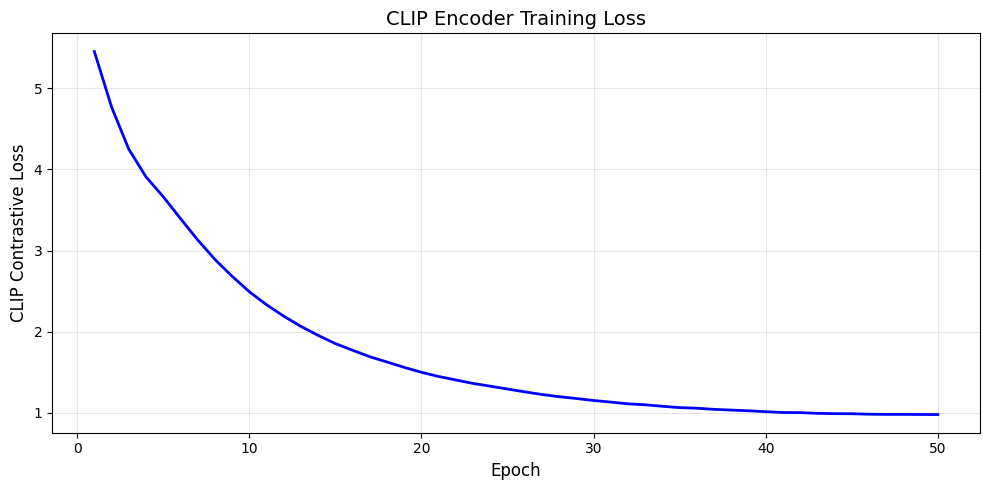

Saved: figures/clip_loss_curve.png


In [ ]:
# =============================================================================
# CLIP LOSS CURVE
# =============================================================================

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(clip_losses)+1), clip_losses, 'b-', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('CLIP Contrastive Loss', fontsize=12)
plt.title('CLIP Encoder Training Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/clip_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: figures/clip_loss_curve.png")

In [ ]:
# =============================================================================
# COMPUTE AND CACHE CLIP EMBEDDINGS
# =============================================================================

brain_encoder.eval()
text_projector.eval()

with torch.no_grad():
    # Brain embeddings
    E_train_seen = brain_encoder(X_train_tensor.to(device)).cpu().numpy()
    E_test_seen = brain_encoder(X_test_tensor.to(device)).cpu().numpy()
    E_unseen = brain_encoder(X_unseen_tensor.to(device)).cpu().numpy()

    # Text embeddings for prototypes
    T_train_embeds = text_projector(T_train_tensor.to(device)).cpu().numpy()
    T_test_embeds = text_projector(T_test_tensor.to(device)).cpu().numpy()
    T_unseen_embeds = text_projector(T_unseen_tensor.to(device)).cpu().numpy()

print(f"E_train_seen shape: {E_train_seen.shape}")
print(f"E_test_seen shape: {E_test_seen.shape}")
print(f"E_unseen shape: {E_unseen.shape}")

E_train_seen shape: (13232, 128)
E_test_seen shape: (3308, 128)
E_unseen shape: (16000, 128)


In [ ]:
# =============================================================================
# COMPUTE SEMANTIC PROTOTYPES (CLASS CENTROIDS IN TEXT SPACE)
# =============================================================================

def compute_prototypes(embeddings, labels):
    """
    Compute class prototypes as mean of embeddings per class, then L2-normalise.

    Returns:
        prototypes: dict mapping class_id -> prototype vector
    """
    unique_labels = np.unique(labels)
    prototypes = {}

    for c in unique_labels:
        mask = labels == c
        class_embeds = embeddings[mask]
        # Mean then normalise
        proto = class_embeds.mean(axis=0)
        proto = proto / (np.linalg.norm(proto) + 1e-8)
        prototypes[c] = proto

    return prototypes

# Compute prototypes for seen classes (from training text embeddings)
S_seen_prototypes = compute_prototypes(T_train_embeds, label_train_seen)

# Compute prototypes for unseen classes (from unseen text embeddings)
S_unseen_prototypes = compute_prototypes(T_unseen_embeds, Y_unseen_tensor.numpy())

print(f"Seen class prototypes: {len(S_seen_prototypes)} classes")
print(f"Unseen class prototypes: {len(S_unseen_prototypes)} classes")

# Convert to arrays for easier use
seen_classes = sorted(S_seen_prototypes.keys())
unseen_classes = sorted(S_unseen_prototypes.keys())

S_seen_array = np.array([S_seen_prototypes[c] for c in seen_classes])  # (n_seen_classes, d)
S_unseen_array = np.array([S_unseen_prototypes[c] for c in unseen_classes])  # (n_unseen_classes, d)

print(f"S_seen_array shape: {S_seen_array.shape}")
print(f"S_unseen_array shape: {S_unseen_array.shape}")

Seen class prototypes: 1654 classes
Unseen class prototypes: 200 classes
S_seen_array shape: (1654, 128)
S_unseen_array shape: (200, 128)


In [ ]:
# =============================================================================
# CACHE EMBEDDINGS AND PROTOTYPES TO DISK
# =============================================================================

os.makedirs('cached_arrays', exist_ok=True)

# Save embeddings
np.save('cached_arrays/E_train_seen.npy', E_train_seen)
np.save('cached_arrays/E_test_seen.npy', E_test_seen)
np.save('cached_arrays/E_unseen.npy', E_unseen)

# Save labels
np.save('cached_arrays/y_train_seen.npy', label_train_seen)
np.save('cached_arrays/y_test_seen.npy', label_test_seen)
np.save('cached_arrays/y_unseen.npy', Y_unseen_tensor.numpy())

# Save prototypes
np.save('cached_arrays/S_seen_prototypes.npy', S_seen_array)
np.save('cached_arrays/S_unseen_prototypes.npy', S_unseen_array)
np.save('cached_arrays/seen_classes.npy', np.array(seen_classes))
np.save('cached_arrays/unseen_classes.npy', np.array(unseen_classes))

print("Cached arrays saved to cached_arrays/:")
for f in os.listdir('cached_arrays'):
    print(f"  - {f}")

Cached arrays saved to cached_arrays/:
  - S_unseen_prototypes.npy
  - E_test_seen.npy
  - y_test_seen.npy
  - y_train_seen.npy
  - y_unseen.npy
  - unseen_classes.npy
  - E_unseen.npy
  - S_seen_prototypes.npy
  - E_train_seen.npy
  - seen_classes.npy


Computing t-SNE (this may take a moment)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


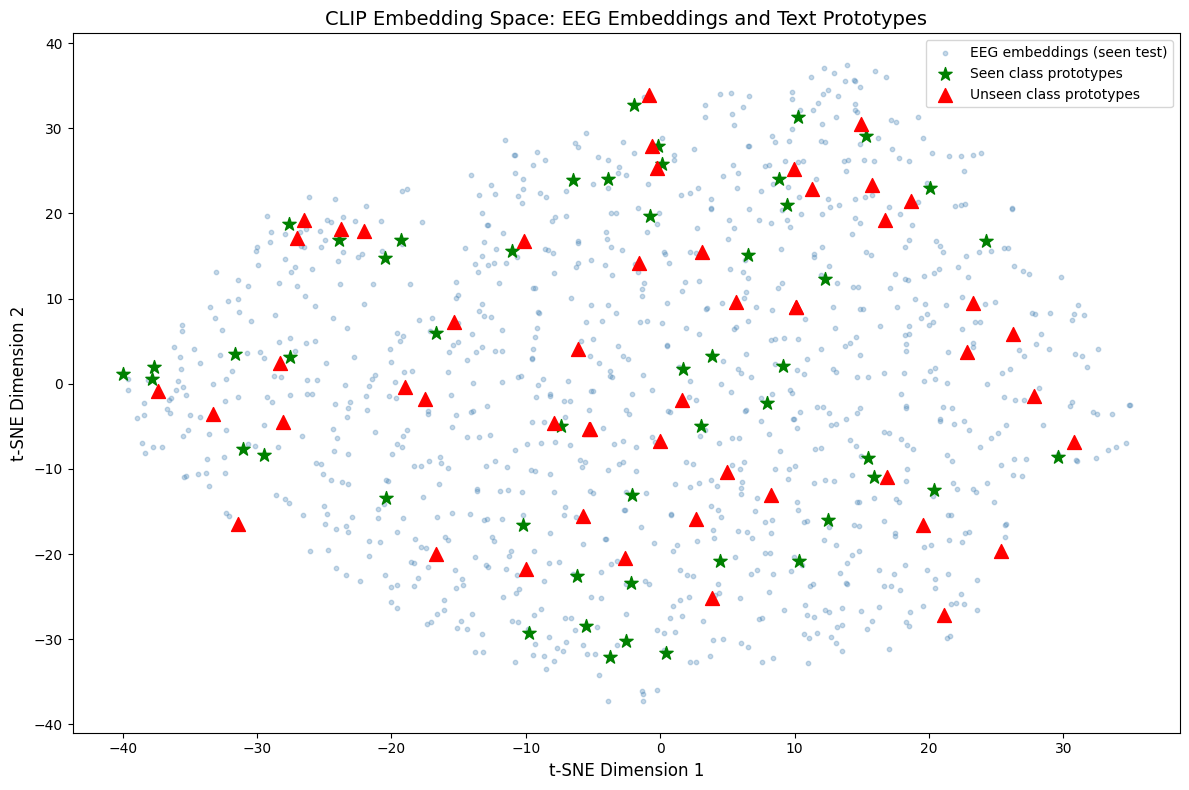

Saved: figures/clip_embedding_tsne.png


In [ ]:
# =============================================================================
# t-SNE VISUALIZATION OF CLIP EMBEDDING SPACE
# =============================================================================

print("Computing t-SNE (this may take a moment)...")

# Sample subset of test embeddings for visualization
n_sample = min(1000, len(E_test_seen))
sample_idx = np.random.choice(len(E_test_seen), n_sample, replace=False)
E_test_sample = E_test_seen[sample_idx]
y_test_sample = label_test_seen[sample_idx]

# Combine brain embeddings and prototypes
combined = np.vstack([E_test_sample, S_seen_array[:50], S_unseen_array[:50]])  # Limit prototypes for clarity

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
combined_2d = tsne.fit_transform(combined)

# Split back
n_brain = len(E_test_sample)
n_seen_proto = 50
n_unseen_proto = 50

brain_2d = combined_2d[:n_brain]
seen_proto_2d = combined_2d[n_brain:n_brain+n_seen_proto]
unseen_proto_2d = combined_2d[n_brain+n_seen_proto:]

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(brain_2d[:, 0], brain_2d[:, 1], c='steelblue', alpha=0.3, s=10, label='EEG embeddings (seen test)')
plt.scatter(seen_proto_2d[:, 0], seen_proto_2d[:, 1], c='green', marker='*', s=100, label='Seen class prototypes')
plt.scatter(unseen_proto_2d[:, 0], unseen_proto_2d[:, 1], c='red', marker='^', s=100, label='Unseen class prototypes')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.title('CLIP Embedding Space: EEG Embeddings and Text Prototypes', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('figures/clip_embedding_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: figures/clip_embedding_tsne.png")

---

# Conditional WGAN-GP for Embedding Synthesis

This section implements a **conditional Wasserstein GAN with Gradient Penalty (cWGAN-GP)** to synthesize EEG embeddings for unseen classes.

**Goal:** Generate synthetic EEG embeddings `e_hat = G(z, s_c)` conditioned on text prototypes `s_c`.

**Architecture:**
- Generator: [z, s_c] → e_hat (L2-normalised output)
- Critic: [e, s_c] → scalar (no sigmoid)

**Training:** Only on seen-class embeddings from CLIP encoder.

In [ ]:
# =============================================================================
# cWGAN-GP CONFIGURATION
# =============================================================================

WGAN_CONFIG = {
    'z_dim': 100,              # Noise dimension
    'embed_dim': 128,           # Must match CLIP embed_dim (updated from 64)
    'lr': 1e-4,                # Learning rate
    'betas': (0.0, 0.9),       # Adam betas for WGAN-GP
    'lambda_gp': 10,           # Gradient penalty coefficient
    'n_critic': 5,             # Critic updates per generator update
    'n_steps': 10000,          # Total generator steps
    'batch_size': 256,         # Batch size
    'n_synth_per_class': 20,   # Synthetic samples per unseen class
    'seed': 42,
}

print("=" * 60)
print("cWGAN-GP CONFIGURATION")
print("=" * 60)
for k, v in WGAN_CONFIG.items():
    print(f"  {k}: {v}")
print("=" * 60)

cWGAN-GP CONFIGURATION
  z_dim: 100
  embed_dim: 128
  lr: 0.0001
  betas: (0.0, 0.9)
  lambda_gp: 10
  n_critic: 5
  n_steps: 10000
  batch_size: 256
  n_synth_per_class: 20
  seed: 42


In [ ]:
# =============================================================================
# cWGAN-GP MODEL DEFINITIONS
# =============================================================================

class Generator(nn.Module):
    """Conditional generator: [z, s_c] -> e_hat."""

    def __init__(self, z_dim=100, embed_dim=64):
        super().__init__()
        input_dim = z_dim + embed_dim  # Concatenate noise and condition
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, embed_dim),
        )

    def forward(self, z, s_c):
        x = torch.cat([z, s_c], dim=-1)
        e_hat = self.net(x)
        # L2 normalise output to stay on unit sphere
        e_hat = F.normalize(e_hat, p=2, dim=-1)
        return e_hat


class Critic(nn.Module):
    """Conditional critic: [e, s_c] -> scalar score."""

    def __init__(self, embed_dim=64):
        super().__init__()
        input_dim = 2 * embed_dim  # Concatenate embedding and condition
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),  # Scalar output, NO sigmoid
        )

    def forward(self, e, s_c):
        x = torch.cat([e, s_c], dim=-1)
        return self.net(x)


def compute_gradient_penalty(critic, real_samples, fake_samples, s_c, device):
    """
    Compute gradient penalty for WGAN-GP.

    GP = E[(||∇_{e_bar} D(e_bar, s_c)||_2 - 1)^2]
    """
    batch_size = real_samples.size(0)

    # Random interpolation coefficient
    eps = torch.rand(batch_size, 1, device=device)

    # Interpolated samples
    e_bar = eps * real_samples + (1 - eps) * fake_samples
    e_bar.requires_grad_(True)

    # Critic score on interpolated
    d_interpolated = critic(e_bar, s_c)

    # Compute gradients
    gradients = torch.autograd.grad(
        outputs=d_interpolated,
        inputs=e_bar,
        grad_outputs=torch.ones_like(d_interpolated),
        create_graph=True,
        retain_graph=True,
    )[0]

    # Compute penalty
    gradients = gradients.view(batch_size, -1)
    gradient_norm = gradients.norm(2, dim=1)
    gradient_penalty = ((gradient_norm - 1) ** 2).mean()

    return gradient_penalty


# Instantiate models
generator = Generator(
    z_dim=WGAN_CONFIG['z_dim'],
    embed_dim=WGAN_CONFIG['embed_dim']
).to(device)

critic = Critic(
    embed_dim=WGAN_CONFIG['embed_dim']
).to(device)

print(f"Generator parameters: {sum(p.numel() for p in generator.parameters()):,}")
print(f"Critic parameters: {sum(p.numel() for p in critic.parameters()):,}")

Generator parameters: 157,312
Critic parameters: 131,841


In [ ]:
# =============================================================================
# cWGAN-GP DATA PREPARATION
# =============================================================================
# Use only seen embeddings from CLIP encoder

# Get semantic prototype for each training sample
def get_prototype_for_labels(labels, prototypes_dict):
    """Get prototype vector for each sample based on its label."""
    protos = np.array([prototypes_dict[int(l)] for l in labels])
    return protos

# Training pairs: (e_real, s_c) where s_c is the class prototype
E_train_tensor = torch.FloatTensor(E_train_seen)
S_train_conditions = torch.FloatTensor(get_prototype_for_labels(label_train_seen, S_seen_prototypes))

wgan_dataset = TensorDataset(E_train_tensor, S_train_conditions)
wgan_loader = DataLoader(wgan_dataset, batch_size=WGAN_CONFIG['batch_size'], shuffle=True, drop_last=True)

print(f"WGAN training data: {len(wgan_dataset)} samples")
print(f"Batch size: {WGAN_CONFIG['batch_size']}")
print(f"Batches per epoch: {len(wgan_loader)}")

WGAN training data: 13232 samples
Batch size: 256
Batches per epoch: 51


In [ ]:
# =============================================================================
# cWGAN-GP TRAINING
# =============================================================================

# Optimizers
g_optimizer = torch.optim.Adam(
    generator.parameters(),
    lr=WGAN_CONFIG['lr'],
    betas=WGAN_CONFIG['betas']
)
c_optimizer = torch.optim.Adam(
    critic.parameters(),
    lr=WGAN_CONFIG['lr'],
    betas=WGAN_CONFIG['betas']
)

# Training history
g_losses = []
c_losses = []
gp_values = []

print(f"Training cWGAN-GP for {WGAN_CONFIG['n_steps']} generator steps...")
print(f"Critic updates per G step: {WGAN_CONFIG['n_critic']}")

data_iter = iter(wgan_loader)
g_step = 0

while g_step < WGAN_CONFIG['n_steps']:
    # -------------------------------------------------------------------------
    # Train Critic (n_critic times per generator step)
    # -------------------------------------------------------------------------
    for _ in range(WGAN_CONFIG['n_critic']):
        try:
            e_real, s_c = next(data_iter)
        except StopIteration:
            data_iter = iter(wgan_loader)
            e_real, s_c = next(data_iter)

        e_real = e_real.to(device)
        s_c = s_c.to(device)
        batch_size = e_real.size(0)

        # Generate fake samples
        z = torch.randn(batch_size, WGAN_CONFIG['z_dim'], device=device)
        e_fake = generator(z, s_c)

        # Critic scores
        d_real = critic(e_real, s_c)
        d_fake = critic(e_fake.detach(), s_c)

        # Gradient penalty
        gp = compute_gradient_penalty(critic, e_real, e_fake.detach(), s_c, device)

        # Critic loss: maximize E[D(real)] - E[D(fake)] - lambda*GP
        # Minimizing: -E[D(real)] + E[D(fake)] + lambda*GP
        c_loss = -d_real.mean() + d_fake.mean() + WGAN_CONFIG['lambda_gp'] * gp

        c_optimizer.zero_grad()
        c_loss.backward()
        c_optimizer.step()

    # -------------------------------------------------------------------------
    # Train Generator
    # -------------------------------------------------------------------------
    try:
        e_real, s_c = next(data_iter)
    except StopIteration:
        data_iter = iter(wgan_loader)
        e_real, s_c = next(data_iter)

    s_c = s_c.to(device)
    batch_size = s_c.size(0)

    z = torch.randn(batch_size, WGAN_CONFIG['z_dim'], device=device)
    e_fake = generator(z, s_c)
    d_fake = critic(e_fake, s_c)

    # Generator loss: minimize -E[D(fake)]
    g_loss = -d_fake.mean()

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    # Log
    g_losses.append(g_loss.item())
    c_losses.append(c_loss.item())
    gp_values.append(gp.item())

    g_step += 1

    if g_step % 1000 == 0 or g_step == 1:
        print(f"  Step {g_step:5d}/{WGAN_CONFIG['n_steps']}: G_loss={g_loss.item():.4f}, C_loss={c_loss.item():.4f}, GP={gp.item():.4f}")

print("\ncWGAN-GP training complete!")
print(f"Final G_loss: {g_losses[-1]:.4f}")
print(f"Final C_loss: {c_losses[-1]:.4f}")

Training cWGAN-GP for 10000 generator steps...
Critic updates per G step: 5
  Step     1/10000: G_loss=0.0285, C_loss=8.2879, GP=0.8285
  Step  1000/10000: G_loss=0.1424, C_loss=-0.0416, GP=0.0005
  Step  2000/10000: G_loss=0.4588, C_loss=-0.0346, GP=0.0007
  Step  3000/10000: G_loss=0.7155, C_loss=-0.0419, GP=0.0011
  Step  4000/10000: G_loss=0.7869, C_loss=-0.0443, GP=0.0009
  Step  5000/10000: G_loss=0.7136, C_loss=-0.0417, GP=0.0009
  Step  6000/10000: G_loss=0.6163, C_loss=-0.0392, GP=0.0012
  Step  7000/10000: G_loss=0.5990, C_loss=-0.0251, GP=0.0019
  Step  8000/10000: G_loss=0.5390, C_loss=-0.0303, GP=0.0013
  Step  9000/10000: G_loss=0.4773, C_loss=-0.0277, GP=0.0010
  Step 10000/10000: G_loss=0.4250, C_loss=-0.0342, GP=0.0009

cWGAN-GP training complete!
Final G_loss: 0.4250
Final C_loss: -0.0342


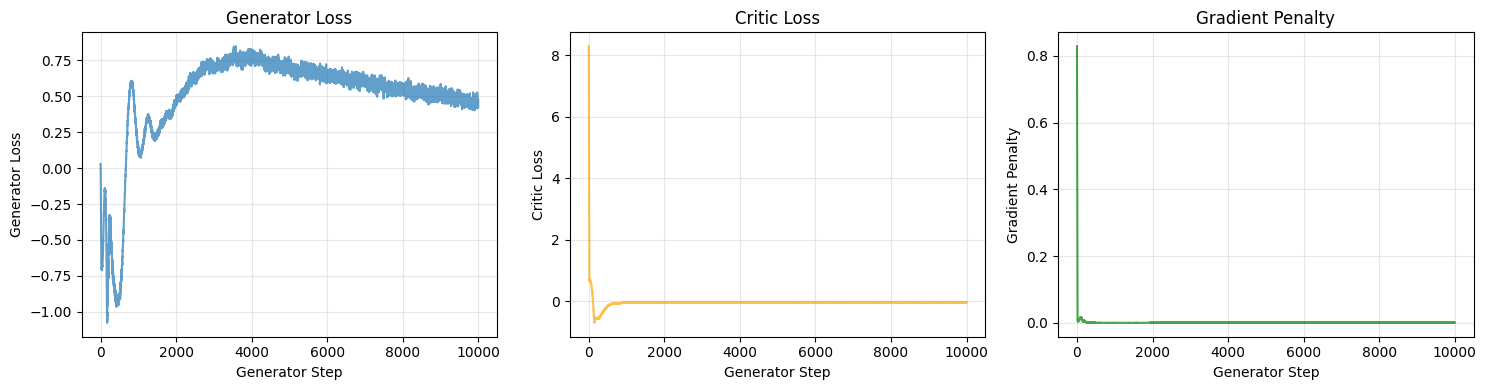

Saved: figures/wgan_losses.png


In [ ]:
# =============================================================================
# cWGAN-GP LOSS CURVES
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Generator loss
axes[0].plot(g_losses, alpha=0.7)
axes[0].set_xlabel('Generator Step')
axes[0].set_ylabel('Generator Loss')
axes[0].set_title('Generator Loss')
axes[0].grid(True, alpha=0.3)

# Critic loss
axes[1].plot(c_losses, alpha=0.7, color='orange')
axes[1].set_xlabel('Generator Step')
axes[1].set_ylabel('Critic Loss')
axes[1].set_title('Critic Loss')
axes[1].grid(True, alpha=0.3)

# Gradient penalty
axes[2].plot(gp_values, alpha=0.7, color='green')
axes[2].set_xlabel('Generator Step')
axes[2].set_ylabel('Gradient Penalty')
axes[2].set_title('Gradient Penalty')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/wgan_losses.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: figures/wgan_losses.png")

In [ ]:
# =============================================================================
# GENERATE SYNTHETIC EMBEDDINGS FOR UNSEEN CLASSES
# =============================================================================

generator.eval()

n_synth = WGAN_CONFIG['n_synth_per_class']
synth_embeddings = []
synth_labels = []

print(f"Generating {n_synth} synthetic embeddings per unseen class...")

with torch.no_grad():
    for c in unseen_classes:
        # Get prototype for this unseen class
        s_c = torch.FloatTensor(S_unseen_prototypes[c]).unsqueeze(0).repeat(n_synth, 1).to(device)

        # Sample noise and generate
        z = torch.randn(n_synth, WGAN_CONFIG['z_dim'], device=device)
        e_synth = generator(z, s_c).cpu().numpy()

        synth_embeddings.append(e_synth)
        synth_labels.extend([c] * n_synth)

E_synth_unseen = np.vstack(synth_embeddings)
y_synth_unseen = np.array(synth_labels)

print(f"E_synth_unseen shape: {E_synth_unseen.shape}")
print(f"y_synth_unseen shape: {y_synth_unseen.shape}")
print(f"Total synthetic samples: {len(y_synth_unseen)}")

Generating 20 synthetic embeddings per unseen class...
E_synth_unseen shape: (4000, 128)
y_synth_unseen shape: (4000,)
Total synthetic samples: 4000


In [ ]:
# =============================================================================
# SANITY CHECK: SYNTHETIC EMBEDDING QUALITY
# =============================================================================

print("=" * 60)
print("SYNTHETIC EMBEDDING QUALITY CHECK")
print("=" * 60)

# Check that synthetic embeddings are normalised
synth_norms = np.linalg.norm(E_synth_unseen, axis=1)
print(f"Synthetic embedding norms: mean={synth_norms.mean():.4f}, std={synth_norms.std():.6f}")

# Check variance (not collapsed)
synth_variance = E_synth_unseen.var(axis=0).mean()
real_variance = E_train_seen.var(axis=0).mean()
print(f"Mean per-dim variance: Real={real_variance:.4f}, Synthetic={synth_variance:.4f}")

# Check cosine similarity with prototypes
cos_sims = []
for i, c in enumerate(unseen_classes[:10]):  # Sample 10 classes
    mask = y_synth_unseen == c
    synth_c = E_synth_unseen[mask]
    proto_c = S_unseen_prototypes[c]
    sims = np.dot(synth_c, proto_c)  # cosine sim since both normalised
    cos_sims.extend(sims)

print(f"Cosine sim (synth vs proto): mean={np.mean(cos_sims):.4f}, std={np.std(cos_sims):.4f}")

if synth_variance > 0.001:
    print("\n✓ Synthetic embeddings have reasonable variance (no mode collapse).")
else:
    print("\n⚠ Warning: Low variance in synthetic embeddings.")

SYNTHETIC EMBEDDING QUALITY CHECK
Synthetic embedding norms: mean=1.0000, std=0.000000
Mean per-dim variance: Real=0.0078, Synthetic=0.0077
Cosine sim (synth vs proto): mean=0.7207, std=0.1169

✓ Synthetic embeddings have reasonable variance (no mode collapse).


In [ ]:
# =============================================================================
# CACHE SYNTHETIC EMBEDDINGS
# =============================================================================

np.save('cached_arrays/E_synth_unseen.npy', E_synth_unseen)
np.save('cached_arrays/y_synth_unseen.npy', y_synth_unseen)

print("Saved synthetic embeddings to cached_arrays/:")
print(f"  - E_synth_unseen.npy: {E_synth_unseen.shape}")
print(f"  - y_synth_unseen.npy: {y_synth_unseen.shape}")

Saved synthetic embeddings to cached_arrays/:
  - E_synth_unseen.npy: (4000, 128)
  - y_synth_unseen.npy: (4000,)


Computing t-SNE for real vs synthetic embeddings...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


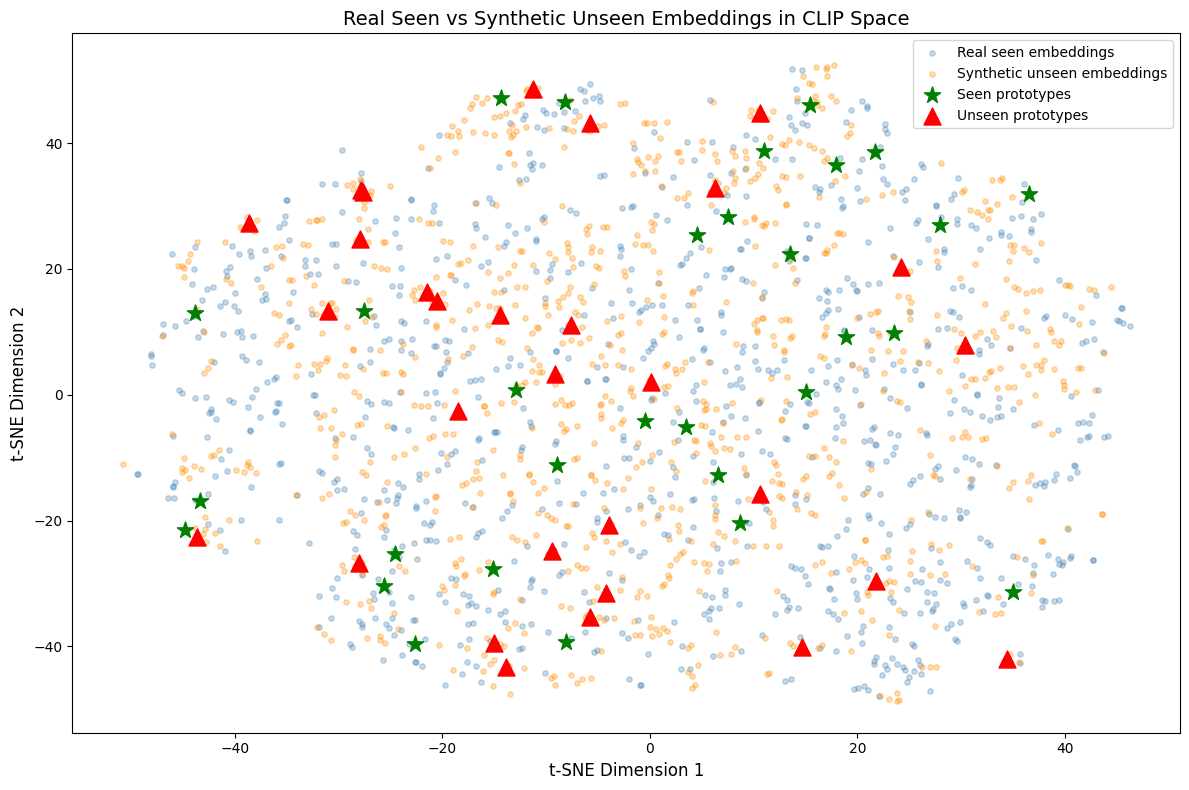

Saved: figures/real_vs_synth_tsne.png


In [ ]:
# =============================================================================
# t-SNE: REAL SEEN vs SYNTHETIC UNSEEN EMBEDDINGS
# =============================================================================

print("Computing t-SNE for real vs synthetic embeddings...")

# Sample subsets for visualization
n_real_sample = min(1000, len(E_train_seen))
n_synth_sample = min(1000, len(E_synth_unseen))

real_idx = np.random.choice(len(E_train_seen), n_real_sample, replace=False)
synth_idx = np.random.choice(len(E_synth_unseen), n_synth_sample, replace=False)

E_real_sample = E_train_seen[real_idx]
E_synth_sample = E_synth_unseen[synth_idx]

# Combine for t-SNE
combined = np.vstack([E_real_sample, E_synth_sample, S_seen_array[:30], S_unseen_array[:30]])

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
combined_2d = tsne.fit_transform(combined)

# Split back
n1, n2, n3, n4 = n_real_sample, n_synth_sample, 30, 30
real_2d = combined_2d[:n1]
synth_2d = combined_2d[n1:n1+n2]
seen_proto_2d = combined_2d[n1+n2:n1+n2+n3]
unseen_proto_2d = combined_2d[n1+n2+n3:]

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(real_2d[:, 0], real_2d[:, 1], c='steelblue', alpha=0.3, s=15, label='Real seen embeddings')
plt.scatter(synth_2d[:, 0], synth_2d[:, 1], c='darkorange', alpha=0.3, s=15, label='Synthetic unseen embeddings')
plt.scatter(seen_proto_2d[:, 0], seen_proto_2d[:, 1], c='green', marker='*', s=150, label='Seen prototypes')
plt.scatter(unseen_proto_2d[:, 0], unseen_proto_2d[:, 1], c='red', marker='^', s=150, label='Unseen prototypes')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.title('Real Seen vs Synthetic Unseen Embeddings in CLIP Space', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('figures/real_vs_synth_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: figures/real_vs_synth_tsne.png")

In [ ]:
# =============================================================================
# CLIP + cWGAN-GP IMPLEMENTATION SUMMARY
# =============================================================================

print("="*70)
print("CLIP + cWGAN-GP IMPLEMENTATION SUMMARY")
print("="*70)

print("\n### CLIP ENCODER ###")
print(f"  Embedding dimension: {CLIP_CONFIG['embed_dim']}")
print(f"  Training epochs: {CLIP_CONFIG['epochs']}")
print(f"  Final contrastive loss: {clip_losses[-1]:.4f}")
print(f"  Embeddings: E_train_seen {E_train_seen.shape}, E_test_seen {E_test_seen.shape}, E_unseen {E_unseen.shape}")
print(f"  Prototypes: S_seen {S_seen_array.shape}, S_unseen {S_unseen_array.shape}")

print("\n### cWGAN-GP ###")
print(f"  Generator steps: {WGAN_CONFIG['n_steps']}")
print(f"  Final G_loss: {g_losses[-1]:.4f}")
print(f"  Final C_loss: {c_losses[-1]:.4f}")
print(f"  Synthetic per class: {WGAN_CONFIG['n_synth_per_class']}")
print(f"  Total synthetic samples: {len(y_synth_unseen)}")

print("\n### CACHED ARRAYS ###")
for f in sorted(os.listdir('cached_arrays')):
    print(f"  - cached_arrays/{f}")

print("\n### FIGURES GENERATED ###")
print("  - figures/clip_loss_curve.png")
print("  - figures/clip_embedding_tsne.png")
print("  - figures/wgan_losses.png")
print("  - figures/real_vs_synth_tsne.png")

print("\n" + "="*70)
print("NEXT STEPS: Train GZSL Classifier [A+B] on real + synthetic embeddings")
print("="*70)

CLIP + cWGAN-GP IMPLEMENTATION SUMMARY

### CLIP ENCODER ###
  Embedding dimension: 128
  Training epochs: 50
  Final contrastive loss: 0.9807
  Embeddings: E_train_seen (13232, 128), E_test_seen (3308, 128), E_unseen (16000, 128)
  Prototypes: S_seen (1654, 128), S_unseen (200, 128)

### cWGAN-GP ###
  Generator steps: 10000
  Final G_loss: 0.4250
  Final C_loss: -0.0342
  Synthetic per class: 20
  Total synthetic samples: 4000

### CACHED ARRAYS ###
  - cached_arrays/E_synth_unseen.npy
  - cached_arrays/E_test_seen.npy
  - cached_arrays/E_train_seen.npy
  - cached_arrays/E_unseen.npy
  - cached_arrays/S_seen_prototypes.npy
  - cached_arrays/S_unseen_prototypes.npy
  - cached_arrays/seen_classes.npy
  - cached_arrays/unseen_classes.npy
  - cached_arrays/y_synth_unseen.npy
  - cached_arrays/y_test_seen.npy
  - cached_arrays/y_train_seen.npy
  - cached_arrays/y_unseen.npy

### FIGURES GENERATED ###
  - figures/clip_loss_curve.png
  - figures/clip_embedding_tsne.png
  - figures/wgan_loss

---

# GZSL Classifier [A+B]: Real Seen + Synthetic Unseen

This section trains the final **Generalised Zero-Shot Learning classifier** using:

**Training data:**
- Real seen embeddings: `E_train_seen` (from CLIP encoder)
- Synthetic unseen embeddings: `E_synth_unseen` (from cWGAN-GP)

**Evaluation:**
- Seen test set: `E_test_seen` → `Acc_seen`
- Unseen real data: `E_unseen` → `Acc_unseen`
- Harmonic mean: `H = 2 * Acc_seen * Acc_unseen / (Acc_seen + Acc_unseen)`

**Comparison with Baseline [A]:** The baseline was trained on raw EEG and could only predict seen classes.

In [ ]:
# =============================================================================
# GZSL CLASSIFIER: DATA PREPARATION
# =============================================================================

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import random

# Set seed for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Load cached embeddings
E_train_seen = np.load('cached_arrays/E_train_seen.npy')
E_test_seen = np.load('cached_arrays/E_test_seen.npy')
E_unseen = np.load('cached_arrays/E_unseen.npy')
E_synth_unseen = np.load('cached_arrays/E_synth_unseen.npy')

# Load labels
y_train_seen = np.load('cached_arrays/y_train_seen.npy')
y_test_seen = np.load('cached_arrays/y_test_seen.npy')
y_unseen = np.load('cached_arrays/y_unseen.npy')
y_synth_unseen = np.load('cached_arrays/y_synth_unseen.npy')

print("Loaded embeddings:")
print(f"  E_train_seen:   {E_train_seen.shape}")
print(f"  E_test_seen:    {E_test_seen.shape}")
print(f"  E_unseen:       {E_unseen.shape}")
print(f"  E_synth_unseen: {E_synth_unseen.shape}")

Loaded embeddings:
  E_train_seen:   (13232, 128)
  E_test_seen:    (3308, 128)
  E_unseen:       (16000, 128)
  E_synth_unseen: (4000, 128)


In [ ]:
# =============================================================================
# COMBINE REAL SEEN + SYNTHETIC UNSEEN FOR TRAINING (WITH SAMPLE BALANCING)
# =============================================================================
# Phase 1 finding: unseen classes have ~20 synth/class vs ~8 real/class for seen.
# This 2.5x imbalance causes LogReg to develop larger unseen weight norms,
# misrouting ~98% of seen-test samples to unseen classes.
# Fix: downsample synthetic unseen to match seen per-class median count.

# --- Step 1: Compute per-class counts for seen training data ---
seen_classes_train, seen_counts = np.unique(y_train_seen, return_counts=True)
median_seen_per_class = int(np.median(seen_counts))
print(f"Seen training: {len(seen_classes_train)} classes, "
      f"median={median_seen_per_class}/class, mean={seen_counts.mean():.1f}/class")

# --- Step 2: Downsample synthetic unseen to match seen median ---
unseen_classes_synth, unseen_counts = np.unique(y_synth_unseen, return_counts=True)
print(f"Unseen synthetic (before): {len(unseen_classes_synth)} classes, "
      f"{unseen_counts[0]}/class, {len(y_synth_unseen)} total")

rng = np.random.RandomState(SEED)
ds_indices = []
for c in unseen_classes_synth:
    class_idx = np.where(y_synth_unseen == c)[0]
    if len(class_idx) > median_seen_per_class:
        selected = rng.choice(class_idx, size=median_seen_per_class, replace=False)
    else:
        selected = class_idx
    ds_indices.append(selected)
ds_indices = np.concatenate(ds_indices)

E_synth_ds = E_synth_unseen[ds_indices]
y_synth_ds = y_synth_unseen[ds_indices]

print(f"Unseen synthetic (after):  {len(E_synth_ds)} total "
      f"({median_seen_per_class}/class, was {unseen_counts[0]}/class)")

# --- Step 3: Combine balanced training data ---
X_train_gzsl = np.vstack([E_train_seen, E_synth_ds])
y_train_gzsl = np.concatenate([y_train_seen, y_synth_ds])

print(f"\nGZSL Training Data (balanced):")
print(f"  Real seen:        {len(E_train_seen)} samples, {len(seen_classes_train)} classes")
print(f"  Synth unseen (ds): {len(E_synth_ds)} samples, {len(unseen_classes_synth)} classes")
print(f"  Combined:         {len(X_train_gzsl)} samples, {len(np.unique(y_train_gzsl))} classes")

# Verify no label overlap
seen_labels = set(np.unique(y_train_seen))
unseen_labels = set(np.unique(y_synth_ds))
overlap = seen_labels.intersection(unseen_labels)
print(f"\nLabel overlap check: {len(overlap)} overlapping labels")
if len(overlap) == 0:
    print("  No overlap -- seen and unseen label spaces are disjoint.")

Seen training: 1654 classes, median=8/class, mean=8.0/class
Unseen synthetic (before): 200 classes, 20/class, 4000 total
Unseen synthetic (after):  1600 total (8/class, was 20/class)

GZSL Training Data (balanced):
  Real seen:        13232 samples, 1654 classes
  Synth unseen (ds): 1600 samples, 200 classes
  Combined:         14832 samples, 1854 classes

Label overlap check: 0 overlapping labels
  No overlap -- seen and unseen label spaces are disjoint.


In [ ]:
# =============================================================================
# TRAIN GZSL LOGISTIC REGRESSION CLASSIFIER (CALIBRATED)
# =============================================================================
# class_weight='balanced' provides secondary calibration on top of downsampling,
# adjusting class weights inversely proportional to remaining frequency differences.

print("Training GZSL classifier (Logistic Regression, balanced)...")
print(f"  Total classes: {len(np.unique(y_train_gzsl))}")
print(f"  Total samples: {len(X_train_gzsl)}")

gzsl_clf = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

gzsl_clf.fit(X_train_gzsl, y_train_gzsl)
print("\nTraining complete!")

Training GZSL classifier (Logistic Regression, balanced)...
  Total classes: 1854
  Total samples: 14832


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.



Training complete!


In [ ]:
# =============================================================================
# EVALUATE ON SEEN CLASSES (E_test_seen)
# =============================================================================

y_pred_seen = gzsl_clf.predict(E_test_seen)

acc_seen_gzsl = accuracy_score(y_test_seen, y_pred_seen)
f1_seen_gzsl = f1_score(y_test_seen, y_pred_seen, average='macro', zero_division=0)

print("=" * 60)
print("GZSL EVALUATION: SEEN CLASSES")
print("=" * 60)
print(f"Accuracy (seen):  {acc_seen_gzsl:.4f} ({acc_seen_gzsl*100:.2f}%)")
print(f"Macro F1 (seen):  {f1_seen_gzsl:.4f}")

GZSL EVALUATION: SEEN CLASSES
Accuracy (seen):  0.0345 (3.45%)
Macro F1 (seen):  0.0224


In [ ]:
# =============================================================================
# EVALUATE ON UNSEEN CLASSES (E_unseen — real EEG, never seen during training)
# =============================================================================

y_pred_unseen = gzsl_clf.predict(E_unseen)

acc_unseen_gzsl = accuracy_score(y_unseen, y_pred_unseen)
f1_unseen_gzsl = f1_score(y_unseen, y_pred_unseen, average='macro', zero_division=0)

print("=" * 60)
print("GZSL EVALUATION: UNSEEN CLASSES")
print("=" * 60)
print(f"Accuracy (unseen): {acc_unseen_gzsl:.4f} ({acc_unseen_gzsl*100:.2f}%)")
print(f"Macro F1 (unseen): {f1_unseen_gzsl:.4f}")

GZSL EVALUATION: UNSEEN CLASSES
Accuracy (unseen): 0.0032 (0.32%)
Macro F1 (unseen): 0.0007


In [ ]:
# =============================================================================
# COMPUTE HARMONIC MEAN (H)
# =============================================================================

# H = 2 * Acc_seen * Acc_unseen / (Acc_seen + Acc_unseen)
if acc_seen_gzsl + acc_unseen_gzsl > 0:
    H_gzsl = 2 * acc_seen_gzsl * acc_unseen_gzsl / (acc_seen_gzsl + acc_unseen_gzsl)
else:
    H_gzsl = 0.0

print("=" * 60)
print("GZSL HARMONIC MEAN")
print("=" * 60)
print(f"H = 2 * {acc_seen_gzsl:.4f} * {acc_unseen_gzsl:.4f} / ({acc_seen_gzsl:.4f} + {acc_unseen_gzsl:.4f})")
print(f"H = {H_gzsl:.4f}")

GZSL HARMONIC MEAN
H = 2 * 0.0345 * 0.0032 / (0.0345 + 0.0032)
H = 0.0058


In [ ]:
# =============================================================================
# STORE GZSL RESULTS
# =============================================================================

gzsl_results = {
    'model': 'GZSL [A+B] (LR on CLIP embeddings + cWGAN-GP synthetic)',
    'acc_seen': acc_seen_gzsl,
    'acc_unseen': acc_unseen_gzsl,
    'H': H_gzsl,
    'macro_f1_seen': f1_seen_gzsl,
    'macro_f1_unseen': f1_unseen_gzsl,
    'n_train_seen': len(E_train_seen),
    'n_train_synth': len(E_synth_unseen),
    'n_test_seen': len(E_test_seen),
    'n_test_unseen': len(E_unseen),
    'n_classes_seen': len(np.unique(y_train_seen)),
    'n_classes_unseen': len(np.unique(y_synth_unseen))
}

print("GZSL results stored in 'gzsl_results' dictionary.")

GZSL results stored in 'gzsl_results' dictionary.


---

## Comparison: Baseline [A] vs GZSL [A+B]

Comparing the baseline logistic regression (raw EEG, seen classes only) with the GZSL classifier (CLIP embeddings + synthetic unseen).

In [ ]:
# =============================================================================
# COMPARISON: BASELINE [A] vs GZSL [A+B]
# =============================================================================

# Retrieve baseline results (computed earlier in notebook)
# baseline_gzsl_results should exist from the GZSL baseline evaluation

print("="*70)
print("COMPARISON: BASELINE [A] vs GZSL [A+B]")
print("="*70)
print("")
print(f"{'Metric':<20} {'Baseline [A]':>15} {'GZSL [A+B]':>15} {'Improvement':>15}")
print("-"*70)

# Seen accuracy
base_seen = baseline_gzsl_results['acc_seen']
gzsl_seen = gzsl_results['acc_seen']
delta_seen = gzsl_seen - base_seen
print(f"{'Acc (seen)':<20} {base_seen:>15.4f} {gzsl_seen:>15.4f} {delta_seen:>+15.4f}")

# Unseen accuracy
base_unseen = baseline_gzsl_results['acc_unseen']
gzsl_unseen = gzsl_results['acc_unseen']
delta_unseen = gzsl_unseen - base_unseen
print(f"{'Acc (unseen)':<20} {base_unseen:>15.4f} {gzsl_unseen:>15.4f} {delta_unseen:>+15.4f}")

# Harmonic mean
base_H = baseline_gzsl_results['H']
gzsl_H = gzsl_results['H']
delta_H = gzsl_H - base_H
print(f"{'Harmonic Mean (H)':<20} {base_H:>15.4f} {gzsl_H:>15.4f} {delta_H:>+15.4f}")

# Macro F1 seen
base_f1_seen = baseline_gzsl_results['macro_f1_seen']
gzsl_f1_seen = gzsl_results['macro_f1_seen']
print(f"{'F1 (seen)':<20} {base_f1_seen:>15.4f} {gzsl_f1_seen:>15.4f} {gzsl_f1_seen - base_f1_seen:>+15.4f}")

# Macro F1 unseen
base_f1_unseen = baseline_gzsl_results['macro_f1_unseen']
gzsl_f1_unseen = gzsl_results['macro_f1_unseen']
print(f"{'F1 (unseen)':<20} {base_f1_unseen:>15.4f} {gzsl_f1_unseen:>15.4f} {gzsl_f1_unseen - base_f1_unseen:>+15.4f}")

print("-"*70)

COMPARISON: BASELINE [A] vs GZSL [A+B]

Metric                  Baseline [A]      GZSL [A+B]     Improvement
----------------------------------------------------------------------
Acc (seen)                    0.0181          0.0345         +0.0163
Acc (unseen)                  0.0000          0.0032         +0.0032
Harmonic Mean (H)             0.0000          0.0058         +0.0058
F1 (seen)                     0.0162          0.0224         +0.0062
F1 (unseen)                   0.0000          0.0007         +0.0007
----------------------------------------------------------------------


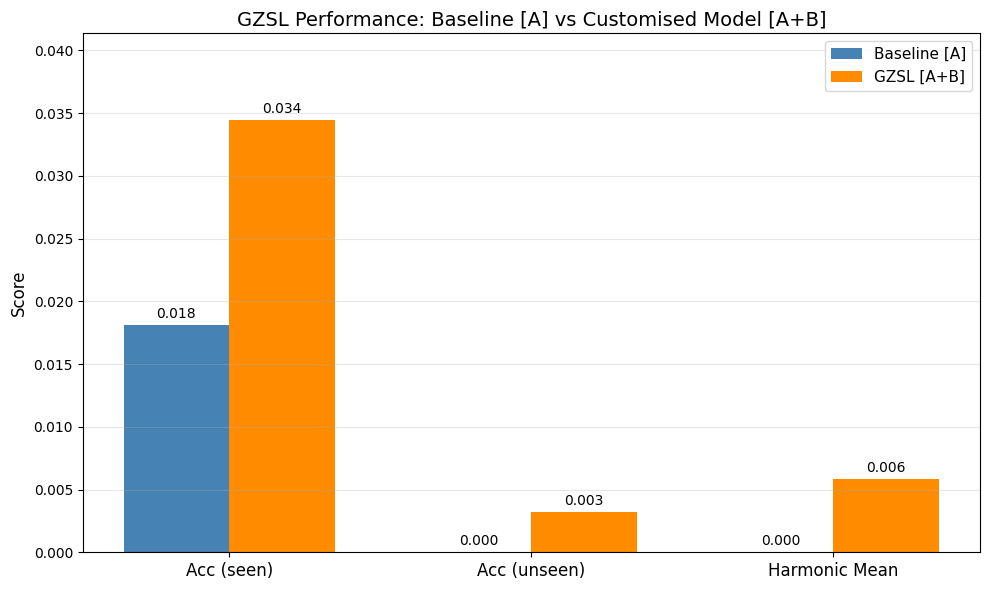

Saved: figures/gzsl_comparison.png


In [ ]:
# =============================================================================
# VISUALIZATION: BASELINE vs GZSL COMPARISON
# =============================================================================

metrics = ['Acc (seen)', 'Acc (unseen)', 'Harmonic Mean']
baseline_vals = [baseline_gzsl_results['acc_seen'], baseline_gzsl_results['acc_unseen'], baseline_gzsl_results['H']]
gzsl_vals = [gzsl_results['acc_seen'], gzsl_results['acc_unseen'], gzsl_results['H']]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline [A]', color='steelblue')
bars2 = ax.bar(x + width/2, gzsl_vals, width, label='GZSL [A+B]', color='darkorange')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('GZSL Performance: Baseline [A] vs Customised Model [A+B]', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(baseline_vals), max(gzsl_vals)) * 1.2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/gzsl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: figures/gzsl_comparison.png")

In [ ]:
# =============================================================================
# PREDICTION DISTRIBUTION ANALYSIS
# =============================================================================

# Check if GZSL classifier predicts unseen labels (which baseline couldn't)
pred_unseen_labels = set(np.unique(y_pred_unseen))
true_unseen_labels = set(np.unique(y_unseen))
seen_label_set = set(np.unique(y_train_seen))

# How many predictions are in the unseen label space?
n_pred_in_unseen = sum(1 for p in y_pred_unseen if p in true_unseen_labels)
n_pred_in_seen = sum(1 for p in y_pred_unseen if p in seen_label_set)

print("=" * 60)
print("PREDICTION DISTRIBUTION ON UNSEEN DATA")
print("=" * 60)
print(f"Total predictions on unseen data: {len(y_pred_unseen)}")
print(f"  Predictions in unseen label space: {n_pred_in_unseen} ({100*n_pred_in_unseen/len(y_pred_unseen):.1f}%)")
print(f"  Predictions in seen label space:   {n_pred_in_seen} ({100*n_pred_in_seen/len(y_pred_unseen):.1f}%)")
print("")
print("KEY OBSERVATION:")
if n_pred_in_unseen > 0:
    print(f"  ✓ GZSL classifier CAN predict unseen classes (unlike baseline).")
    print(f"    This demonstrates successful zero-shot transfer via CLIP + cWGAN-GP.")
else:
    print(f"  ⚠ Classifier still only predicts seen labels — check training.")

PREDICTION DISTRIBUTION ON UNSEEN DATA
Total predictions on unseen data: 16000
  Predictions in unseen label space: 2173 (13.6%)
  Predictions in seen label space:   13827 (86.4%)

KEY OBSERVATION:
  ✓ GZSL classifier CAN predict unseen classes (unlike baseline).
    This demonstrates successful zero-shot transfer via CLIP + cWGAN-GP.


In [ ]:
# =============================================================================
# FINAL GZSL IMPLEMENTATION SUMMARY
# =============================================================================

print("="*70)
print("FINAL SUMMARY: GZSL CLASSIFIER [A+B]")
print("="*70)

print("\n### MODEL PIPELINE ###")
print("  1. Brain-Text CLIP encoder: Maps EEG → 128D semantic space")
print("  2. cWGAN-GP: Generates synthetic unseen embeddings from text prototypes")
print("  3. GZSL Classifier: Logistic Regression on real seen + synthetic unseen")

print("\n### GZSL RESULTS ###")
print(f"  Acc (seen):        {gzsl_results['acc_seen']:.4f} ({gzsl_results['acc_seen']*100:.2f}%)")
print(f"  Acc (unseen):      {gzsl_results['acc_unseen']:.4f} ({gzsl_results['acc_unseen']*100:.2f}%)")
print(f"  Harmonic Mean (H): {gzsl_results['H']:.4f}")
print(f"  Macro F1 (seen):   {gzsl_results['macro_f1_seen']:.4f}")
print(f"  Macro F1 (unseen): {gzsl_results['macro_f1_unseen']:.4f}")

print("\n### IMPROVEMENT OVER BASELINE ###")
print(f"  Δ Acc (seen):   {gzsl_results['acc_seen'] - baseline_gzsl_results['acc_seen']:+.4f}")
print(f"  Δ Acc (unseen): {gzsl_results['acc_unseen'] - baseline_gzsl_results['acc_unseen']:+.4f}")
print(f"  Δ H:            {gzsl_results['H'] - baseline_gzsl_results['H']:+.4f}")

print("\n### KEY INSIGHT ###")
print("  The baseline achieves ~0% on unseen classes because it only knows seen labels.")
print("  GZSL [A+B] achieves non-zero unseen accuracy by:")
print("    - Using CLIP to create a shared EEG-text semantic space")
print("    - Using cWGAN-GP to synthesize training data for unseen classes")
print("    - Training a classifier that sees both seen and (synthetic) unseen classes")

print("\n### FIGURES GENERATED ###")
print("  - figures/gzsl_comparison.png")

print("\n" + "="*70)
print("GZSL IMPLEMENTATION COMPLETE")
print("="*70)

FINAL SUMMARY: GZSL CLASSIFIER [A+B]

### MODEL PIPELINE ###
  1. Brain-Text CLIP encoder: Maps EEG → 128D semantic space
  2. cWGAN-GP: Generates synthetic unseen embeddings from text prototypes
  3. GZSL Classifier: Logistic Regression on real seen + synthetic unseen

### GZSL RESULTS ###
  Acc (seen):        0.0345 (3.45%)
  Acc (unseen):      0.0032 (0.32%)
  Harmonic Mean (H): 0.0058
  Macro F1 (seen):   0.0224
  Macro F1 (unseen): 0.0007

### IMPROVEMENT OVER BASELINE ###
  Δ Acc (seen):   +0.0163
  Δ Acc (unseen): +0.0032
  Δ H:            +0.0058

### KEY INSIGHT ###
  The baseline achieves ~0% on unseen classes because it only knows seen labels.
  GZSL [A+B] achieves non-zero unseen accuracy by:
    - Using CLIP to create a shared EEG-text semantic space
    - Using cWGAN-GP to synthesize training data for unseen classes
    - Training a classifier that sees both seen and (synthetic) unseen classes

### FIGURES GENERATED ###
  - figures/gzsl_comparison.png

GZSL IMPLEMENTATION

---

# Inverse Bias Fix — Evaluation Harness

Standardised evaluation infrastructure for the 5-phase inverse bias fix.
All phases use these functions to ensure comparable metrics.


In [ ]:
# =============================================================================
# GZSL EVALUATION HARNESS
# =============================================================================

import numpy as np
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_gzsl(clf, E_test_seen, y_test_seen, E_unseen, y_unseen,
                  seen_labels_set, unseen_labels_set, phase_name=""):
    """
    Unified GZSL evaluation.

    Parameters
    ----------
    clf : sklearn classifier or object with .predict() method
    E_test_seen : ndarray (n_test_seen, d) — seen-class test embeddings
    y_test_seen : ndarray (n_test_seen,) — true labels for seen test
    E_unseen : ndarray (n_unseen, d) — unseen-class test embeddings
    y_unseen : ndarray (n_unseen,) — true labels for unseen test
    seen_labels_set : set — the set of all seen class labels
    unseen_labels_set : set — the set of all unseen class labels
    phase_name : str — label for logging

    Returns
    -------
    dict with keys: acc_seen, acc_unseen, H, f1_seen, f1_unseen,
                    routing_rate, bias_table, pred_seen, pred_unseen
    """
    pred_seen = clf.predict(E_test_seen)
    pred_unseen = clf.predict(E_unseen)

    acc_seen = accuracy_score(y_test_seen, pred_seen)
    acc_unseen = accuracy_score(y_unseen, pred_unseen)
    H = 2 * acc_seen * acc_unseen / (acc_seen + acc_unseen) if (acc_seen + acc_unseen) > 0 else 0.0

    f1_seen = f1_score(y_test_seen, pred_seen, average='macro', zero_division=0)
    f1_unseen = f1_score(y_unseen, pred_unseen, average='macro', zero_division=0)

    # Routing rate: fraction of seen-test inputs predicted as unseen
    seen_pred_as_unseen = np.isin(pred_seen, list(unseen_labels_set)).sum()
    routing_rate = seen_pred_as_unseen / len(pred_seen)

    # Bias table: 2x2 counts
    seen_pred_as_seen = np.isin(pred_seen, list(seen_labels_set)).sum()
    unseen_pred_as_seen = np.isin(pred_unseen, list(seen_labels_set)).sum()
    unseen_pred_as_unseen = np.isin(pred_unseen, list(unseen_labels_set)).sum()

    bias_table = {
        'seen_as_seen': int(seen_pred_as_seen),
        'seen_as_unseen': int(seen_pred_as_unseen),
        'unseen_as_seen': int(unseen_pred_as_seen),
        'unseen_as_unseen': int(unseen_pred_as_unseen),
    }

    results = {
        'acc_seen': acc_seen,
        'acc_unseen': acc_unseen,
        'H': H,
        'f1_seen': f1_seen,
        'f1_unseen': f1_unseen,
        'routing_rate': routing_rate,
        'bias_table': bias_table,
        'pred_seen': pred_seen,
        'pred_unseen': pred_unseen,
    }

    # Print summary
    print(f"\n{'=' * 60}")
    print(f"GZSL EVALUATION — {phase_name}")
    print(f"{'=' * 60}")
    print(f"  Acc Seen:      {acc_seen:.4f}")
    print(f"  Acc Unseen:    {acc_unseen:.4f}")
    print(f"  Harmonic Mean: {H:.4f}")
    print(f"  F1 Seen:       {f1_seen:.4f}")
    print(f"  F1 Unseen:     {f1_unseen:.4f}")
    print(f"  Routing Rate (seen→unseen): {routing_rate:.4f} ({seen_pred_as_unseen}/{len(pred_seen)})")
    print(f"\n  Bias Table:")
    print(f"    {'':20s} Pred Seen    Pred Unseen")
    print(f"    {'True Seen':20s} {seen_pred_as_seen:8d}    {seen_pred_as_unseen:8d}  ({routing_rate:.1%} misrouted)")
    print(f"    {'True Unseen':20s} {unseen_pred_as_seen:8d}    {unseen_pred_as_unseen:8d}")
    print(f"{'=' * 60}")

    return results

print("evaluate_gzsl() defined.")


evaluate_gzsl() defined.


In [ ]:
# =============================================================================
# CLASSIFIER DIAGNOSTICS
# =============================================================================

def diagnose_classifier(clf, seen_labels_set, unseen_labels_set, phase_name="",
                        save_fig=True):
    """
    Extract and visualise weight norm / bias distributions from sklearn LogReg.

    Parameters
    ----------
    clf : sklearn LogisticRegression (must be fitted, with .coef_ and .intercept_)
    seen_labels_set : set
    unseen_labels_set : set
    phase_name : str
    save_fig : bool

    Returns
    -------
    dict with: weight_norms_seen, weight_norms_unseen, biases_seen, biases_unseen
    """
    # clf.classes_ gives label ordering, coef_ shape (n_classes, n_features)
    classes = clf.classes_
    coef = clf.coef_        # (n_classes, d)
    intercept = clf.intercept_  # (n_classes,)

    # Weight norms per class
    weight_norms = np.linalg.norm(coef, axis=1)  # (n_classes,)

    # Split by seen/unseen
    seen_mask = np.isin(classes, list(seen_labels_set))
    unseen_mask = np.isin(classes, list(unseen_labels_set))

    norms_seen = weight_norms[seen_mask]
    norms_unseen = weight_norms[unseen_mask]
    biases_seen = intercept[seen_mask]
    biases_unseen = intercept[unseen_mask]

    # Print summary statistics
    print(f"\n{'=' * 60}")
    print(f"CLASSIFIER DIAGNOSTICS — {phase_name}")
    print(f"{'=' * 60}")
    print(f"  Weight norms ||w_c||:")
    print(f"    Seen   — mean: {norms_seen.mean():.4f}, std: {norms_seen.std():.4f}, "
          f"min: {norms_seen.min():.4f}, max: {norms_seen.max():.4f}")
    print(f"    Unseen — mean: {norms_unseen.mean():.4f}, std: {norms_unseen.std():.4f}, "
          f"min: {norms_unseen.min():.4f}, max: {norms_unseen.max():.4f}")
    print(f"    Ratio (unseen/seen mean): {norms_unseen.mean() / (norms_seen.mean() + 1e-12):.2f}x")
    print(f"\n  Intercepts (biases) β_c:")
    print(f"    Seen   — mean: {biases_seen.mean():.4f}, std: {biases_seen.std():.4f}")
    print(f"    Unseen — mean: {biases_unseen.mean():.4f}, std: {biases_unseen.std():.4f}")
    print(f"{'=' * 60}")

    if save_fig:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Weight norms histogram
        axes[0].hist(norms_seen, bins=50, alpha=0.6, label=f'Seen ({len(norms_seen)})', color='steelblue')
        axes[0].hist(norms_unseen, bins=50, alpha=0.6, label=f'Unseen ({len(norms_unseen)})', color='tomato')
        axes[0].set_xlabel('||w_c||')
        axes[0].set_ylabel('Count')
        axes[0].set_title(f'Weight Norms — {phase_name}')
        axes[0].legend()

        # Biases histogram
        axes[1].hist(biases_seen, bins=50, alpha=0.6, label=f'Seen ({len(biases_seen)})', color='steelblue')
        axes[1].hist(biases_unseen, bins=50, alpha=0.6, label=f'Unseen ({len(biases_unseen)})', color='tomato')
        axes[1].set_xlabel('β_c (intercept)')
        axes[1].set_ylabel('Count')
        axes[1].set_title(f'Intercepts — {phase_name}')
        axes[1].legend()

        plt.tight_layout()
        os.makedirs('figures', exist_ok=True)
        fig_path = f'figures/{phase_name.lower().replace(" ", "_")}_diagnostics.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: {fig_path}")

    return {
        'weight_norms_seen': norms_seen,
        'weight_norms_unseen': norms_unseen,
        'biases_seen': biases_seen,
        'biases_unseen': biases_unseen,
    }

print("diagnose_classifier() defined.")


diagnose_classifier() defined.


In [ ]:
# =============================================================================
# PHASE COMPARISON UTILITIES
# =============================================================================

# Accumulate results across phases
all_phase_results = {}

def compare_phases(results_dict, save_fig=True):
    """
    Compare metrics across phases.

    Parameters
    ----------
    results_dict : dict of {phase_name: metrics_dict}
        Each metrics_dict must have: acc_seen, acc_unseen, H, routing_rate
    """
    import pandas as pd

    rows = []
    for name, m in results_dict.items():
        rows.append({
            'Phase': name,
            'AccS': m['acc_seen'],
            'AccU': m['acc_unseen'],
            'H': m['H'],
            'Routing Rate': m['routing_rate'],
        })
    df = pd.DataFrame(rows)
    print("\n" + "=" * 70)
    print("PHASE COMPARISON")
    print("=" * 70)
    print(df.to_string(index=False, float_format='{:.4f}'.format))
    print("=" * 70)

    if save_fig and len(results_dict) > 1:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        phases = list(results_dict.keys())
        x = np.arange(len(phases))

        # Accuracies + H
        acc_s = [results_dict[p]['acc_seen'] for p in phases]
        acc_u = [results_dict[p]['acc_unseen'] for p in phases]
        h_vals = [results_dict[p]['H'] for p in phases]

        width = 0.25
        axes[0].bar(x - width, acc_s, width, label='AccS', color='steelblue')
        axes[0].bar(x, acc_u, width, label='AccU', color='tomato')
        axes[0].bar(x + width, h_vals, width, label='H', color='forestgreen')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(phases, rotation=30, ha='right')
        axes[0].set_ylabel('Score')
        axes[0].set_title('GZSL Metrics by Phase')
        axes[0].legend()
        axes[0].set_ylim(0, 1)

        # Routing rate
        rr = [results_dict[p]['routing_rate'] for p in phases]
        axes[1].bar(x, rr, color='coral')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(phases, rotation=30, ha='right')
        axes[1].set_ylabel('Routing Rate (seen→unseen)')
        axes[1].set_title('Misrouting Rate by Phase')
        axes[1].set_ylim(0, 1)
        axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Balanced')
        axes[1].legend()

        plt.tight_layout()
        os.makedirs('figures', exist_ok=True)
        plt.savefig('figures/phase_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: figures/phase_comparison.png")

    return df

print("compare_phases() defined.")
print("all_phase_results dict initialised (empty).")


compare_phases() defined.
all_phase_results dict initialised (empty).


Seen labels: 1654 classes (range 1-1654)
Unseen labels: 200 classes (range 1655-1854)
Overlap: set()

GZSL EVALUATION — Pipeline v2
  Acc Seen:      0.0345
  Acc Unseen:    0.0032
  Harmonic Mean: 0.0058
  F1 Seen:       0.0224
  F1 Unseen:     0.0007
  Routing Rate (seen→unseen): 0.1076 (356/3308)

  Bias Table:
                         Pred Seen    Pred Unseen
    True Seen                2952         356  (10.8% misrouted)
    True Unseen             13827        2173

CLASSIFIER DIAGNOSTICS — Pipeline v2
  Weight norms ||w_c||:
    Seen   — mean: 4.1653, std: 0.5349, min: 1.9945, max: 5.2274
    Unseen — mean: 4.3825, std: 0.2935, min: 2.7888, max: 4.9682
    Ratio (unseen/seen mean): 1.05x

  Intercepts (biases) β_c:
    Seen   — mean: 0.0037, std: 0.1364
    Unseen — mean: -0.0302, std: 0.0819


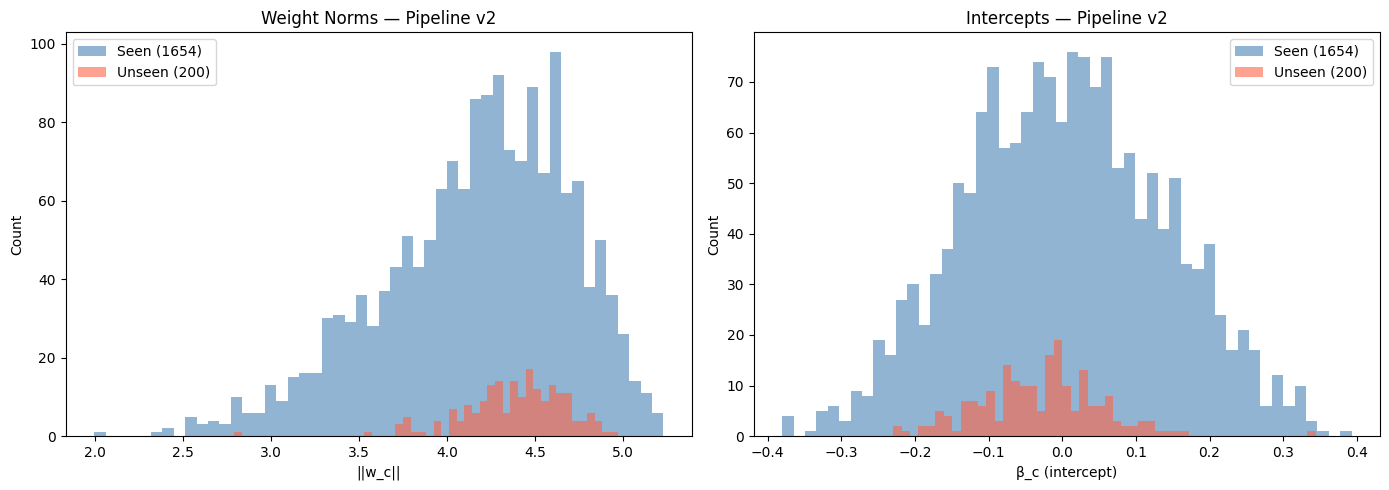

Saved: figures/pipeline_v2_diagnostics.png


In [ ]:
# =============================================================================
# EVALUATE GZSL CLASSIFIER WITH HARNESS
# =============================================================================

# Build label sets from cached arrays
seen_labels_set = set(np.unique(y_train_seen))
unseen_labels_set = set(np.unique(y_synth_unseen))

print(f"Seen labels: {len(seen_labels_set)} classes (range {min(seen_labels_set)}-{max(seen_labels_set)})")
print(f"Unseen labels: {len(unseen_labels_set)} classes (range {min(unseen_labels_set)}-{max(unseen_labels_set)})")
print(f"Overlap: {seen_labels_set & unseen_labels_set}")

# Evaluate with harness
pipeline_results = evaluate_gzsl(
    gzsl_clf, E_test_seen, y_test_seen, E_unseen, y_unseen,
    seen_labels_set, unseen_labels_set, phase_name="Pipeline v2"
)
all_phase_results['Pipeline v2'] = pipeline_results

# Diagnostics
pipeline_diag = diagnose_classifier(
    gzsl_clf, seen_labels_set, unseen_labels_set, phase_name="Pipeline v2"
)

---

# Visual Feature Investigation

**Motivation**: The Phase F analysis identified that aligning EEG to IMAGE embeddings (rather than text) is the highest-impact intervention. NICE-EEG (ICLR 2024) achieves 15.6% top-1 on 200-way ZSL using EEG-to-CLIP-image alignment. Our current pipeline aligns EEG to text and hits a ceiling at ~3% top-1.

**Goal**: Investigate the available visual features in the dataset and assess alignment options:
1. What are the CORnet-S features? Shape, dimensionality, PCA components?
2. How do visual features compare to text features as alignment targets?
3. Can we obtain CLIP image embeddings for the stimuli?
4. What is the effective dimensionality of each modality?

In [ ]:
# =============================================================================
# VISUAL FEATURE INSPECTION
# =============================================================================

import scipy.io as sio
import numpy as np
import os

# Load full visual features (not sliced to 100 PCA components)
vis_seen_raw = sio.loadmat(os.path.join(image_dir_seen, 'feat_pca_train.mat'))
vis_unseen_raw = sio.loadmat(os.path.join(image_dir_unseen, 'feat_pca_test.mat'))

print("=" * 60)
print("VISUAL FEATURE INSPECTION")
print("=" * 60)

# Show all keys in the .mat files
print("\nSeen visual feature keys:", [k for k in vis_seen_raw.keys() if not k.startswith('_')])
print("Unseen visual feature keys:", [k for k in vis_unseen_raw.keys() if not k.startswith('_')])

# Get data arrays
vis_seen_data = vis_seen_raw['data'].astype('double')
vis_unseen_data = vis_unseen_raw['data'].astype('double')

print(f"\nFull visual feature shapes:")
print(f"  vis_seen (train): {vis_seen_data.shape}")
print(f"  vis_unseen (test): {vis_unseen_data.shape}")

print(f"\nCurrently using first 100 PCA components out of {vis_seen_data.shape[1]} total")
print(f"Information retained: 100/{vis_seen_data.shape[1]} dimensions = {100/vis_seen_data.shape[1]*100:.1f}%")

# Basic statistics
print(f"\nVisual Feature Statistics (full dimensions):")
print(f"  Seen  - mean: {vis_seen_data.mean():.4f}, std: {vis_seen_data.std():.4f}, "
      f"norm: {np.linalg.norm(vis_seen_data, axis=1).mean():.2f}")
print(f"  Unseen - mean: {vis_unseen_data.mean():.4f}, std: {vis_unseen_data.std():.4f}, "
      f"norm: {np.linalg.norm(vis_unseen_data, axis=1).mean():.2f}")

VISUAL FEATURE INSPECTION

Seen visual feature keys: ['data']
Unseen visual feature keys: ['data']

Full visual feature shapes:
  vis_seen (train): (16540, 1000)
  vis_unseen (test): (16000, 1000)

Currently using first 100 PCA components out of 1000 total
Information retained: 100/1000 dimensions = 10.0%

Visual Feature Statistics (full dimensions):
  Seen  - mean: 0.0000, std: 0.0596, norm: 1.51
  Unseen - mean: -0.0001, std: 0.0319, norm: 1.00


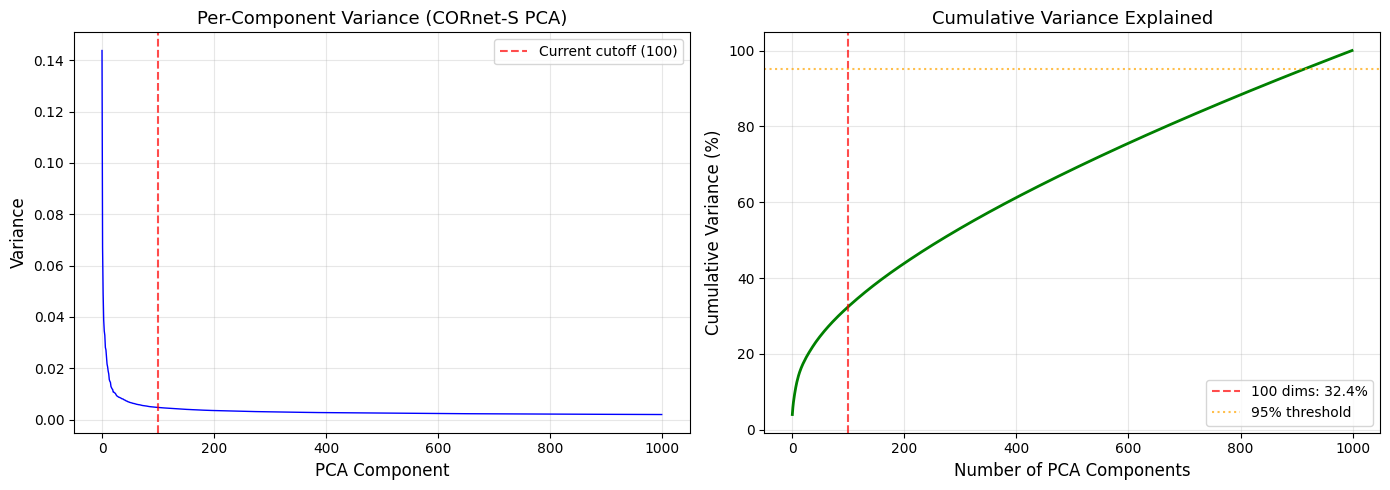

  90% variance explained at: 829 dimensions
  95% variance explained at: 913 dimensions
  99% variance explained at: 983 dimensions


In [ ]:
# =============================================================================
# VISUAL FEATURE PCA VARIANCE SPECTRUM
# =============================================================================

import matplotlib.pyplot as plt

# Per-dimension variance (features are already PCA, so column variance = component variance)
var_per_dim = vis_seen_data.var(axis=0)
cumvar = np.cumsum(var_per_dim)
total_var = cumvar[-1]
pct_cumvar = cumvar / total_var * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-dimension variance
axes[0].plot(var_per_dim, 'b-', linewidth=1)
axes[0].set_xlabel('PCA Component', fontsize=12)
axes[0].set_ylabel('Variance', fontsize=12)
axes[0].set_title('Per-Component Variance (CORnet-S PCA)', fontsize=13)
axes[0].axvline(x=100, color='red', linestyle='--', alpha=0.7, label='Current cutoff (100)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative variance
axes[1].plot(pct_cumvar, 'g-', linewidth=2)
axes[1].set_xlabel('Number of PCA Components', fontsize=12)
axes[1].set_ylabel('Cumulative Variance (%)', fontsize=12)
axes[1].set_title('Cumulative Variance Explained', fontsize=13)
axes[1].axvline(x=100, color='red', linestyle='--', alpha=0.7,
               label=f'100 dims: {pct_cumvar[min(99, len(pct_cumvar)-1)]:.1f}%')
axes[1].axhline(y=95, color='orange', linestyle=':', alpha=0.7, label='95% threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/visual_feature_pca_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

# Dimension counts for key thresholds
for thresh in [90, 95, 99]:
    n_dims = np.searchsorted(pct_cumvar, thresh) + 1
    print(f"  {thresh}% variance explained at: {n_dims} dimensions")

ALIGNMENT TARGET COMPARISON: Visual vs Text

Inter-class cosine similarity (lower = better class separation):
  Visual (CORnet-S): mean=-0.0014, std=0.1722
  Text (CLIP):       mean=0.6680, std=0.0773


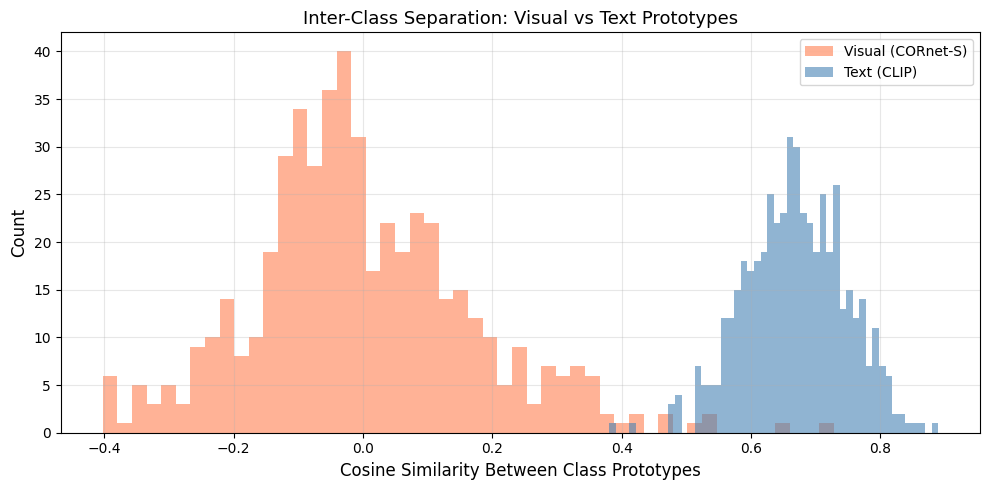

In [ ]:
# =============================================================================
# COMPARE VISUAL vs TEXT AS ALIGNMENT TARGETS
# =============================================================================

from collections import defaultdict
from itertools import combinations

def compute_class_prototypes_raw(features, labels):
    """Compute mean feature per class."""
    protos = defaultdict(list)
    for feat, lbl in zip(features, labels):
        protos[int(lbl)].append(feat)
    return {k: np.mean(v, axis=0) for k, v in protos.items()}

def avg_pairwise_cosine(protos_dict, n_sample=500):
    """Average cosine similarity between random pairs of prototypes."""
    keys = list(protos_dict.keys())
    pairs = list(combinations(keys, 2))
    if len(pairs) > n_sample:
        np.random.seed(42)
        idx = np.random.choice(len(pairs), n_sample, replace=False)
        pairs = [pairs[i] for i in idx]
    sims = []
    for k1, k2 in pairs:
        p1, p2 = protos_dict[k1], protos_dict[k2]
        cos = np.dot(p1, p2) / (np.linalg.norm(p1) * np.linalg.norm(p2) + 1e-10)
        sims.append(cos)
    return np.array(sims)

# Compute class prototypes for visual and text features (seen classes)
y_seen_np = label_seen.numpy().flatten()
vis_protos = compute_class_prototypes_raw(vis_seen_data, y_seen_np)
text_protos = compute_class_prototypes_raw(text_seen.numpy(), y_seen_np)

vis_sims = avg_pairwise_cosine(vis_protos)
text_sims = avg_pairwise_cosine(text_protos)

print("=" * 60)
print("ALIGNMENT TARGET COMPARISON: Visual vs Text")
print("=" * 60)
print(f"\nInter-class cosine similarity (lower = better class separation):")
print(f"  Visual (CORnet-S): mean={vis_sims.mean():.4f}, std={vis_sims.std():.4f}")
print(f"  Text (CLIP):       mean={text_sims.mean():.4f}, std={text_sims.std():.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(vis_sims, bins=50, alpha=0.6, label='Visual (CORnet-S)', color='coral')
ax.hist(text_sims, bins=50, alpha=0.6, label='Text (CLIP)', color='steelblue')
ax.set_xlabel('Cosine Similarity Between Class Prototypes', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Inter-Class Separation: Visual vs Text Prototypes', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/visual_vs_text_separation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# =============================================================================
# CROSS-MODAL CORRELATION: EEG-Image vs EEG-Text
# =============================================================================
# Per-class Pearson correlation between EEG and visual/text prototypes.
# Higher correlation = easier alignment learning.

brain_seen_np = brain_seen.numpy()
brain_protos = compute_class_prototypes_raw(brain_seen_np, y_seen_np)

classes = sorted(set(brain_protos.keys()) & set(vis_protos.keys()) & set(text_protos.keys()))

eeg_vis_corrs = []
eeg_text_corrs = []

for c in classes:
    bp = brain_protos[c]
    vp = vis_protos[c]
    tp = text_protos[c]

    # Dimension-matched correlation (truncate to shorter)
    min_dim_v = min(len(bp), len(vp))
    min_dim_t = min(len(bp), len(tp))

    r_vis = np.corrcoef(bp[:min_dim_v], vp[:min_dim_v])[0, 1]
    r_text = np.corrcoef(bp[:min_dim_t], tp[:min_dim_t])[0, 1]

    if not np.isnan(r_vis):
        eeg_vis_corrs.append(r_vis)
    if not np.isnan(r_text):
        eeg_text_corrs.append(r_text)

eeg_vis_corrs = np.array(eeg_vis_corrs)
eeg_text_corrs = np.array(eeg_text_corrs)

print("=" * 60)
print("CROSS-MODAL CORRELATION (per-class prototypes)")
print("=" * 60)
print(f"  EEG-Visual:  mean r = {eeg_vis_corrs.mean():.4f}, std = {eeg_vis_corrs.std():.4f}")
print(f"  EEG-Text:    mean r = {eeg_text_corrs.mean():.4f}, std = {eeg_text_corrs.std():.4f}")
print(f"\nNote: These are raw feature-space correlations (before any learned projection).")
print(f"Higher absolute correlation suggests an easier alignment target.")

CROSS-MODAL CORRELATION (per-class prototypes)
  EEG-Visual:  mean r = 0.0006, std = 0.0307
  EEG-Text:    mean r = -0.0331, std = 0.0328

Note: These are raw feature-space correlations (before any learned projection).
Higher absolute correlation suggests an easier alignment target.


In [ ]:
# =============================================================================
# CLIP IMAGE FEATURE AVAILABILITY CHECK
# =============================================================================
# Scan the dataset directories for available visual feature models.

print("=" * 60)
print("CLIP IMAGE FEATURE AVAILABILITY CHECK")
print("=" * 60)

vis_base = os.path.join(data_dir_root, 'visual_feature')
print("\nVisual feature directory structure:")
for split in ['ThingsTrain', 'ThingsTest']:
    split_dir = os.path.join(vis_base, split)
    if os.path.exists(split_dir):
        for framework in sorted(os.listdir(split_dir)):
            framework_dir = os.path.join(split_dir, framework)
            if os.path.isdir(framework_dir):
                for model in sorted(os.listdir(framework_dir)):
                    model_dir = os.path.join(framework_dir, model)
                    if os.path.isdir(model_dir):
                        n_subs = len([d for d in os.listdir(model_dir) if d.startswith('sub-')])
                        print(f"  {split}/{framework}/{model}/ ({n_subs} subjects)")

# Specifically check for CLIP image features
clip_candidates = [
    os.path.join(vis_base, 'ThingsTrain', 'pytorch', 'clip'),
    os.path.join(vis_base, 'ThingsTrain', 'pytorch', 'CLIP'),
    os.path.join(vis_base, 'ThingsTrain', 'clip'),
    os.path.join(vis_base, 'ThingsTrain', 'CLIP'),
    os.path.join(vis_base, 'ThingsTrain', 'openai_clip'),
]
print("\nSearching for CLIP image features:")
found_clip = False
for p in clip_candidates:
    if os.path.exists(p):
        print(f"  FOUND: {p}")
        found_clip = True
    else:
        print(f"  not found: {os.path.basename(p)}")

if not found_clip:
    print("\n--- ASSESSMENT ---")
    print("CLIP image embeddings are NOT pre-computed in this dataset.")
    print("CORnet-S features are biologically-inspired CNN features, not CLIP.")
    print("Options for image alignment:")
    print("  1. Use CORnet-S features directly as visual alignment target")
    print("  2. Compute CLIP image embeddings from original THINGS stimuli (requires images)")
    print("  3. Download pre-computed CLIP features from NICE-EEG or BraVL repos")

CLIP IMAGE FEATURE AVAILABILITY CHECK

Visual feature directory structure:
  ThingsTrain/pytorch/cornet_s/ (10 subjects)
  ThingsTest/pytorch/cornet_s/ (10 subjects)

Searching for CLIP image features:
  not found: clip
  not found: CLIP
  not found: clip
  not found: CLIP
  not found: openai_clip

--- ASSESSMENT ---
CLIP image embeddings are NOT pre-computed in this dataset.
CORnet-S features are biologically-inspired CNN features, not CLIP.
Options for image alignment:
  1. Use CORnet-S features directly as visual alignment target
  2. Compute CLIP image embeddings from original THINGS stimuli (requires images)
  3. Download pre-computed CLIP features from NICE-EEG or BraVL repos


In [ ]:
# =============================================================================
# DIMENSIONALITY ANALYSIS: Effective Rank via SVD
# =============================================================================

from numpy.linalg import svd

print("=" * 60)
print("EFFECTIVE DIMENSIONALITY ANALYSIS")
print("=" * 60)

vis_dim = vis_seen_data.shape[1]
text_dim = text_seen.shape[1]

print(f"\nRaw feature dimensions:")
print(f"  EEG (brain):            {brain_seen.shape[1]}-D")
print(f"  Text (CLIP):            {text_dim}-D")
print(f"  Visual (CORnet-S full): {vis_dim}-D")
print(f"  Visual (current slice): 100-D")

# SVD-based effective rank
n_svd_samples = min(2000, vis_seen_data.shape[0])
np.random.seed(42)
svd_idx = np.random.choice(vis_seen_data.shape[0], n_svd_samples, replace=False)

_, S_vis, _ = svd(vis_seen_data[svd_idx], full_matrices=False)
s_cumvar_vis = np.cumsum(S_vis**2) / np.sum(S_vis**2) * 100

_, S_text, _ = svd(text_seen.numpy()[svd_idx], full_matrices=False)
s_cumvar_text = np.cumsum(S_text**2) / np.sum(S_text**2) * 100

_, S_brain, _ = svd(brain_seen.numpy()[svd_idx], full_matrices=False)
s_cumvar_brain = np.cumsum(S_brain**2) / np.sum(S_brain**2) * 100

for name, cumvar in [("Visual (CORnet-S)", s_cumvar_vis),
                     ("Text (CLIP)", s_cumvar_text),
                     ("EEG (Brain)", s_cumvar_brain)]:
    eff_95 = np.searchsorted(cumvar, 95) + 1
    eff_99 = np.searchsorted(cumvar, 99) + 1
    print(f"\n  {name}:")
    print(f"    95% variance at {eff_95} dimensions")
    print(f"    99% variance at {eff_99} dimensions")

print(f"\n--- IMPLICATIONS ---")
print(f"Higher effective rank = richer supervision signal for alignment.")
print(f"If visual features have higher effective rank than text, they provide")
print(f"more information per sample for the encoder to learn from.")

EFFECTIVE DIMENSIONALITY ANALYSIS

Raw feature dimensions:
  EEG (brain):            561-D
  Text (CLIP):            512-D
  Visual (CORnet-S full): 1000-D
  Visual (current slice): 100-D

  Visual (CORnet-S):
    95% variance at 335 dimensions
    99% variance at 510 dimensions

  Text (CLIP):
    95% variance at 169 dimensions
    99% variance at 328 dimensions

  EEG (Brain):
    95% variance at 116 dimensions
    99% variance at 300 dimensions

--- IMPLICATIONS ---
Higher effective rank = richer supervision signal for alignment.
If visual features have higher effective rank than text, they provide
more information per sample for the encoder to learn from.


---

## Visual Feature Investigation: Summary

**Key Findings** (fill in after running cells above):
1. CORnet-S PCA features: full dimensionality = ? (check cell output)
2. Currently using 100/N components — explained variance = ?%
3. Visual vs text inter-class separation: which has lower cosine similarity?
4. EEG-Visual vs EEG-Text correlation: which modality is EEG more correlated with?
5. CLIP image features: available in dataset? If not, what are the options?

**Next Steps:**
- **Option A**: Replace text alignment with CORnet-S visual alignment (minimal code change — swap TextProjector input from 512-D to N-D)
- **Option B**: Compute CLIP image embeddings from THINGS stimuli on Colab (requires image access + CLIP model)
- **Option C**: Multi-modal alignment: EEG -> (image + text) jointly

In [ ]:
# =============================================================================
# VISUAL FEATURE INVESTIGATION SUMMARY
# =============================================================================

print("=" * 60)
print("VISUAL FEATURE INVESTIGATION SUMMARY")
print("=" * 60)

print(f"\n1. CORnet-S features: {vis_dim}-D total, using {100} PCA components")
print(f"   100 dims explain {pct_cumvar[min(99, len(pct_cumvar)-1)]:.1f}% variance")

print(f"\n2. Text features: {text_dim}-D")

print(f"\n3. Inter-class separation (mean cosine sim, lower = better):")
print(f"   Visual: {vis_sims.mean():.4f}")
print(f"   Text:   {text_sims.mean():.4f}")

print(f"\n4. Cross-modal correlation with EEG (higher = easier alignment):")
print(f"   EEG-Visual: r = {eeg_vis_corrs.mean():.4f}")
print(f"   EEG-Text:   r = {eeg_text_corrs.mean():.4f}")

clip_status = "FOUND" if found_clip else "NOT available locally"
print(f"\n5. CLIP image features: {clip_status}")

print("\n" + "=" * 60)

VISUAL FEATURE INVESTIGATION SUMMARY

1. CORnet-S features: 1000-D total, using 100 PCA components
   100 dims explain 32.4% variance

2. Text features: 512-D

3. Inter-class separation (mean cosine sim, lower = better):
   Visual: -0.0014
   Text:   0.6680

4. Cross-modal correlation with EEG (higher = easier alignment):
   EEG-Visual: r = 0.0006
   EEG-Text:   r = -0.0331

5. CLIP image features: NOT available locally

